# Team-6 전체 파이프라인 통합 노트북

이 노트북은 프로젝트의 단계별 노트북을 하나로 합쳐서 전체 분석 흐름을 검토하기 위한 통합 노트북입니다.
1단계 원본 데이터 다운로드 및 샘플링은 Kaggle API와 Yelp 원본 JSON이 필요하므로,
외부 검토자는 이미 생성된 data/interim, data/processed, data/embeddings 파일을 기준으로
2단계 이후 또는 4단계 모델링 파트를 실행하는 것을 권장합니다.

# 1단계 EDA 및 도시별 샘플링

Yelp 원본 JSON에서 분석 대상 도시의 레스토랑 리뷰를 추출하고, 감성 라벨을 만든 뒤 도시별 15,000건 샘플 CSV를 저장합니다. 마지막 섹션에서는 샘플 품질을 확인하는 표와 그래프를 `output/`에 함께 저장합니다.

노트북 위치: `notebooks/01_eda_sampling/`


In [1]:
from google.colab import drive
from google.colab import files
from pathlib import Path

# 1. 내 구글 드라이브 연동 (결과물을 저장하기 위함)
drive.mount('/content/drive')

PROJECT_ROOT = Path('/content/drive/MyDrive/ml_project/Team-6')
INTERIM_DIR = PROJECT_ROOT / 'data' / 'interim'
FIGURE_DIR = PROJECT_ROOT / 'output' / 'figures'
TABLE_DIR = PROJECT_ROOT / 'output' / 'tables'
for directory in [INTERIM_DIR, FIGURE_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# 2. 캐글 API 토큰(kaggle.json) 업로드
print("캐글에서 다운받은 kaggle.json 파일을 업로드해주세요.")
files.upload()

Mounted at /content/drive
캐글에서 다운받은 kaggle.json 파일을 업로드해주세요.


KeyboardInterrupt: 

## 1. 실행 환경 및 데이터 준비

이 단계는 원본 Yelp 데이터를 다시 내려받아 샘플 CSV를 만드는 재생성용 구간입니다. 실행 환경에 따라 경로가 달라질 수 있으므로, 먼저 아래 두 가지를 확인해야 합니다.

- **Colab에서 실행하는 경우:** Google Drive를 마운트한 뒤 `PROJECT_ROOT`를 본인 Drive의 프로젝트 폴더로 맞춥니다. 예: `/content/drive/MyDrive/.../Team-6`
- **로컬에서 실행하는 경우:** 저장소를 `git clone`한 위치가 사람마다 다르므로, 고정 절대경로 대신 현재 저장소 루트를 기준으로 `data/`, `output/` 폴더를 찾도록 경로를 확인합니다.

또한 원본 Yelp JSON은 GitHub에 포함하지 않으므로, 1단계를 처음부터 실행하려면 Kaggle API 토큰과 원본 데이터 다운로드가 필요합니다. 단순 검토 목적이라면 이미 포함된 `data/interim/`, `data/processed/`, `data/embeddings/`의 CSV를 기준으로 이후 단계를 확인하는 것이 더 적합합니다.


In [ ]:
# 캐글 폴더 세팅 및 권한 부여
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Yelp 데이터셋 다운로드 (약 1~2분 소요)
!kaggle datasets download -d yelp-dataset/yelp-dataset

# 코랩 임시 공간에 압축 풀기 (드라이브에 푸는 것보다 수십 배 빠름)
!unzip -q yelp-dataset.zip -d /content/yelp_data
print("데이터 다운로드 및 압축 해제 완료!")

In [ ]:
import pandas as pd

# 비즈니스 데이터 불러오기
biz_path = '/content/yelp_data/yelp_academic_dataset_business.json'
biz_df = pd.read_json(biz_path, lines=True)

# 'Restaurants' 카테고리 필터링 (결측치 처리 포함)
biz_df = biz_df[biz_df['categories'].fillna('').str.contains('Restaurants')]

# 필라델피아 도시 필터링
target_city = 'Philadelphia'
biz_city = biz_df[biz_df['city'] == target_city]

# 추출할 식당들의 고유 ID 리스트 확보
target_biz_ids = set(biz_city['business_id'].tolist()) # 검색 속도를 위해 set으로 변환
print(f"{target_city} 내 대상 식당 개수: {len(target_biz_ids)}개")

## 2. Philadelphia 샘플 생성

비즈니스 JSON에서 Philadelphia 레스토랑 `business_id`를 먼저 추출한 뒤, 리뷰 JSON을 청크 단위로 읽어 해당 식당 리뷰만 남깁니다.


In [ ]:
review_path = '/content/yelp_data/yelp_academic_dataset_review.json'
chunk_size = 100000
review_chunks = []

print("리뷰 데이터 청크 필터링 시작... (약 3~5분 소요 예상)")

# 10만 줄씩 잘라서 읽기
for chunk in pd.read_json(review_path, lines=True, chunksize=chunk_size):
    # 대상 식당 ID에 해당하는 리뷰만 남기기
    filtered_chunk = chunk[chunk['business_id'].isin(target_biz_ids)]
    review_chunks.append(filtered_chunk)

# 모아둔 조각들을 하나의 데이터프레임으로 병합
review_subset = pd.concat(review_chunks, ignore_index=True)
print(f"필터링된 총 리뷰 개수: {len(review_subset)}개")

In [ ]:
# 1. 3점 리뷰(중립) 제거
review_subset = review_subset[review_subset['stars'] != 3]

# 2. 4~5점은 1(긍정), 1~2점은 0(부정)으로 매핑
review_subset['is_positive'] = review_subset['stars'].apply(lambda x: 1 if x > 3 else 0)

# 3. 15,000개 무작위 샘플링 (10,000개 이상 요건 충족)
final_dataset = review_subset.sample(n=15000, random_state=42)

print("최종 샘플링 데이터 크기:", final_dataset.shape)
display(final_dataset.head(3))

In [ ]:
# 내 구글 드라이브의 원하는 경로 지정 (예: Colab Notebooks 폴더)
save_path = INTERIM_DIR / 'yelp_subset_philly_15k.csv'

# CSV 파일로 영구 저장
final_dataset.to_csv(save_path, index=False)

print(f"저장 완료. 경로: {save_path}")
print("코랩 세션이 초기화되어도 저장된 CSV에서 전처리를 이어갈 수 있습니다.")

In [ ]:
import pandas as pd

# 비즈니스 데이터 불러오기
biz_path = '/content/yelp_data/yelp_academic_dataset_business.json'
biz_df = pd.read_json(biz_path, lines=True)

# 'Restaurants' 카테고리 필터링 (결측치 처리 포함)
biz_df = biz_df[biz_df['categories'].fillna('').str.contains('Restaurants')]

# 투손(Tucson) 도시 필터링 적용
target_city = 'Tucson'
biz_city = biz_df[biz_df['city'] == target_city]

# 추출할 식당들의 고유 ID 리스트 확보
target_biz_ids = set(biz_city['business_id'].tolist())
print(f"{target_city} 내 대상 식당 개수: {len(target_biz_ids)}개")

In [ ]:
review_path = '/content/yelp_data/yelp_academic_dataset_review.json'
chunk_size = 100000
review_chunks = []

print(f"{target_city} 리뷰 데이터 청크 필터링 시작... (약 3~5분 소요 예상)")

# 10만 줄씩 잘라서 읽기
for chunk in pd.read_json(review_path, lines=True, chunksize=chunk_size):
    # 대상 식당 ID에 해당하는 리뷰만 남기기
    filtered_chunk = chunk[chunk['business_id'].isin(target_biz_ids)]
    review_chunks.append(filtered_chunk)

# 모아둔 조각들을 하나의 데이터프레임으로 병합
review_subset = pd.concat(review_chunks, ignore_index=True)
print(f"필터링된 총 리뷰 개수: {len(review_subset)}개")

## 3. Tucson 샘플 생성

동일한 기준으로 Tucson 레스토랑 리뷰를 필터링하고 3점 중립 리뷰를 제거한 뒤 15,000건을 샘플링합니다.


In [ ]:
# 1. 3점 리뷰(중립) 제거
review_subset = review_subset[review_subset['stars'] != 3]

# 2. 4~5점은 1(긍정), 1~2점은 0(부정)으로 매핑
review_subset['is_positive'] = review_subset['stars'].apply(lambda x: 1 if x > 3 else 0)

# 3. 15,000개 무작위 샘플링
final_dataset = review_subset.sample(n=15000, random_state=42)

print("최종 샘플링 데이터 크기:", final_dataset.shape)

display(final_dataset.head(3))

In [ ]:
# 내 구글 드라이브의 원하는 경로 지정 (Tucson 파일명 적용)
save_path = INTERIM_DIR / 'yelp_subset_tucson_15k.csv'

# CSV 파일로 영구 저장
final_dataset.to_csv(save_path, index=False)

print(f"저장 완료. 경로: {save_path}")
print("투손 지역 15,000개 리뷰 데이터를 저장했습니다.")

In [ ]:
import pandas as pd

# 비즈니스 데이터 불러오기
biz_path = '/content/yelp_data/yelp_academic_dataset_business.json'
biz_df = pd.read_json(biz_path, lines=True)

# 'Restaurants' 카테고리 필터링 (결측치 처리 포함)
biz_df = biz_df[biz_df['categories'].fillna('').str.contains('Restaurants')]

# 뉴올리언스(New Orleans) 도시 필터링 적용
target_city = 'New Orleans'
biz_city = biz_df[biz_df['city'] == target_city]

# 추출할 식당들의 고유 ID 리스트 확보
target_biz_ids = set(biz_city['business_id'].tolist())
print(f"{target_city} 내 대상 식당 개수: {len(target_biz_ids)}개")

In [ ]:
review_path = '/content/yelp_data/yelp_academic_dataset_review.json'
chunk_size = 100000
review_chunks = []

print(f"{target_city} 리뷰 데이터 청크 필터링 시작...")

# 10만 줄씩 잘라서 읽기
for chunk in pd.read_json(review_path, lines=True, chunksize=chunk_size):
    # 대상 식당 ID에 해당하는 리뷰만 남기기
    filtered_chunk = chunk[chunk['business_id'].isin(target_biz_ids)]
    review_chunks.append(filtered_chunk)

# 모아둔 조각들을 하나의 데이터프레임으로 병합
review_subset = pd.concat(review_chunks, ignore_index=True)
print(f"필터링된 총 리뷰 개수: {len(review_subset)}개")

In [ ]:
# 1. 3점 리뷰(중립) 제거
review_subset = review_subset[review_subset['stars'] != 3]

# 2. 4~5점은 1(긍정), 1~2점은 0(부정)으로 매핑
review_subset['is_positive'] = review_subset['stars'].apply(lambda x: 1 if x > 3 else 0)

# 3. 15,000개 무작위 샘플링
final_dataset = review_subset.sample(n=15000, random_state=42)

print("최종 샘플링 데이터 크기:", final_dataset.shape)
display(final_dataset.head(3))

## 4. New Orleans 샘플 생성

New Orleans도 같은 파이프라인을 적용하여 도시별 비교가 가능한 입력 CSV를 만듭니다.


In [ ]:
# 내 구글 드라이브의 원하는 경로 지정 (New Orleans 파일명 적용)
save_path = INTERIM_DIR / 'yelp_subset_new_orleans_15k.csv'

# CSV 파일로 영구 저장
final_dataset.to_csv(save_path, index=False)

print(f"저장 완료. 경로: {save_path}")
print("뉴올리언스 지역 15,000개 리뷰 데이터를 저장했습니다.")

In [ ]:
# 1. 코랩 리눅스 시스템에 나눔 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 2. 설치된 폰트를 Matplotlib의 기본 폰트로 설정
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

# 3. 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## 5. 샘플 EDA 및 시각화 저장

각 도시 샘플의 타깃 분포, 텍스트 길이, 워드클라우드를 확인하고 PNG 파일을 `output/figures/`에 저장합니다.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

BASE_STOPWORDS = {
    "food", "place", "restaurant", "good", "great", "time", "one",
    "really", "even", "came", "went", "got", "make", "will", "go",
    "ordered", "us", "back", "much", "well"
}


def save_figure(filename):
    path = FIGURE_DIR / filename
    plt.savefig(path, dpi=160, bbox_inches='tight')
    print(f"그래프 저장 완료: {path}")


def plot_city_eda(city_name, city_slug, input_file, extra_stopwords=None):
    file_path = INTERIM_DIR / input_file
    df = pd.read_csv(file_path)
    df['text_length'] = df['text'].astype(str).apply(len)

    summary_table = df.groupby('is_positive').agg(
        review_count=('review_id', 'count'),
        avg_stars=('stars', 'mean'),
        avg_text_length=('text_length', 'mean'),
    ).reset_index()
    summary_path = TABLE_DIR / f'eda_{city_slug}_summary.csv'
    summary_table.to_csv(summary_path, index=False)
    print(f"[{city_name}] 요약표 저장 완료: {summary_path}")
    display(summary_table)

    plt.figure(figsize=(8, 6))
    ax = sns.countplot(data=df, x='is_positive', hue='is_positive', palette=['#ff9999', '#66b3ff'], legend=False)
    plt.title(f'{city_name} 리뷰 만족도 분포', fontsize=16, fontweight='bold')
    plt.xlabel('만족도 (0: 불만족, 1: 만족)', fontsize=12)
    plt.ylabel('리뷰 개수', fontsize=12)
    for patch in ax.patches:
        height = patch.get_height()
        ax.text(patch.get_x() + patch.get_width() / 2, height + 50, f'{int(height):,}', ha='center', size=12)
    plt.tight_layout()
    save_figure(f'eda_{city_slug}_target_distribution.png')
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='is_positive', y='text_length', hue='is_positive', palette=['#ff9999', '#66b3ff'], legend=False)
    plt.title(f'{city_name} 만족도별 리뷰 텍스트 길이', fontsize=16, fontweight='bold')
    plt.xlabel('만족도 (0: 불만족, 1: 만족)', fontsize=12)
    plt.ylabel('리뷰 길이 (글자 수)', fontsize=12)
    plt.ylim(0, df['text_length'].quantile(0.95))
    plt.tight_layout()
    save_figure(f'eda_{city_slug}_text_length_boxplot.png')
    plt.show()

    pos_text = " ".join(review for review in df[df['is_positive'] == 1]['text'].astype(str))
    neg_text = " ".join(review for review in df[df['is_positive'] == 0]['text'].astype(str))
    custom_stopwords = set(STOPWORDS) | BASE_STOPWORDS | set(extra_stopwords or [])

    wc_pos = WordCloud(width=600, height=400, background_color='white', colormap='Greens', stopwords=custom_stopwords, max_words=100).generate(pos_text)
    wc_neg = WordCloud(width=600, height=400, background_color='white', colormap='Reds', stopwords=custom_stopwords, max_words=100).generate(neg_text)

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    axes[0].imshow(wc_pos, interpolation='bilinear')
    axes[0].set_title('만족(긍정) 핵심 키워드', fontsize=18, fontweight='bold')
    axes[0].axis('off')
    axes[1].imshow(wc_neg, interpolation='bilinear')
    axes[1].set_title('불만족(부정) 위기 키워드', fontsize=18, fontweight='bold')
    axes[1].axis('off')
    plt.tight_layout()
    save_figure(f'eda_{city_slug}_wordcloud.png')
    plt.show()


### 필라델피아 EDA

샘플의 타깃 불균형, 텍스트 길이, 긍정/부정 키워드를 확인합니다.


In [ ]:
plot_city_eda('Philadelphia', 'philly', 'yelp_subset_philly_15k.csv')

### 투손 EDA

도시명이 워드클라우드에 과도하게 반영되지 않도록 Tucson 관련 단어를 stopword에 추가합니다.


In [ ]:
plot_city_eda('Tucson', 'tucson', 'yelp_subset_tucson_15k.csv', extra_stopwords=['Tucson', 'tucson'])

### 뉴올리언스 EDA

New Orleans/NOLA 표현이 핵심 키워드를 가리지 않도록 도시명 관련 단어를 제외합니다.


In [ ]:
plot_city_eda('New Orleans', 'new_orleans', 'yelp_subset_new_orleans_15k.csv', extra_stopwords=['New Orlean', 'New Orleans', 'NOLA', 'nola', 'new orleans', 'New', 'Orlean'])

---

# 2-1단계. 사업장 위치 CSV 생성

원본 사업장 JSON에서 위치 정보만 추출해 `data/interim/business_location.csv`를 만듭니다.

원본 노트북: `notebooks/02_feature_engineering/Create_Business_Location_CSV.ipynb`


# 사업장 위치 CSV 생성

원본 `yelp_academic_dataset_business.json`에서 피처 엔지니어링에 필요한 위치 정보만 추출합니다.

생성 파일:

```text
business_location.csv
```

포함 컬럼:

```text
business_id, city, state, latitude, longitude
```

## 1. 경로 설정

이 노트북은 실행 환경마다 프로젝트 위치가 달라질 수 있다는 점을 전제로 봐야 합니다. 핵심은 `PROJECT_ROOT`가 현재 저장소의 최상위 폴더(`Team-6/`)를 가리키도록 맞추는 것입니다.

- **로컬 실행:** `git clone`한 위치는 사용자마다 다르므로, 현재 작업 디렉터리 또는 상위 폴더를 탐색해 `data/`가 있는 저장소 루트를 찾습니다. 원본 `yelp_academic_dataset_business.json`이 없다면 `BUSINESS_JSON_PATH`를 실제 파일 위치로 수정해야 합니다.
- **Colab 실행:** Google Drive를 마운트한 뒤, `PROJECT_ROOT`와 `BUSINESS_JSON_PATH`를 본인 Drive 구조에 맞게 확인합니다.

즉, 아래 코드의 절대경로는 예시이며 모든 환경에서 그대로 동작한다고 가정하면 안 됩니다. 외부 실행자는 먼저 `PROJECT_ROOT`, `BUSINESS_JSON_PATH`, `OUTPUT_PATH`가 본인 환경에서 올바른지 확인해야 합니다.


In [11]:
from pathlib import Path
import pandas as pd


def running_in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ModuleNotFoundError:
        return False


IN_COLAB = running_in_colab()

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    PROJECT_ROOT = Path('/content/drive/MyDrive/ml_project/Team-6')
    BUSINESS_JSON_PATH = PROJECT_ROOT / 'data' / 'yelp_academic_dataset_business.json'
else:
    PROJECT_ROOT = Path.cwd().resolve()
    for path in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        if path.name == 'Team-6':
            PROJECT_ROOT = path
            break

    BUSINESS_JSON_PATH = PROJECT_ROOT.parent / 'archive' / 'yelp_academic_dataset_business.json'

OUTPUT_DIR = PROJECT_ROOT / 'data' / 'interim'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH = OUTPUT_DIR / 'business_location.csv'

print(f'코랩 실행 여부: {IN_COLAB}')
print(f'프로젝트 루트: {PROJECT_ROOT}')
print(f'사업장 JSON 경로: {BUSINESS_JSON_PATH}')
print(f'저장 경로: {OUTPUT_PATH}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
코랩 실행 여부: True
프로젝트 루트: /content/drive/MyDrive/ml_project/Team-6
사업장 JSON 경로: /content/drive/MyDrive/ml_project/Team-6/data/yelp_academic_dataset_business.json
저장 경로: /content/drive/MyDrive/ml_project/Team-6/data/interim/business_location.csv


## 2. 원본 JSON 확인

In [13]:
if not BUSINESS_JSON_PATH.exists():
    raise FileNotFoundError(
        '사업장 JSON 파일을 찾을 수 없습니다. '\
        'BUSINESS_JSON_PATH를 실제 파일 경로로 수정해 주세요.\n'
        f'BUSINESS_JSON_PATH: {BUSINESS_JSON_PATH}'
    )

print('사업장 JSON 파일 확인 완료')
print(f'파일 크기(MB): {BUSINESS_JSON_PATH.stat().st_size / 1024 / 1024:.2f}')

FileNotFoundError: 사업장 JSON 파일을 찾을 수 없습니다. BUSINESS_JSON_PATH를 실제 파일 경로로 수정해 주세요.
BUSINESS_JSON_PATH: /content/drive/MyDrive/ml_project/Team-6/data/yelp_academic_dataset_business.json

## 3. 위치 정보 추출

In [7]:
USE_COLUMNS = ['business_id', 'city', 'state', 'latitude', 'longitude']

business_df = pd.read_json(BUSINESS_JSON_PATH, lines=True)
business_location = business_df[USE_COLUMNS].copy()

business_location = business_location.dropna(subset=['business_id'])
business_location = business_location.drop_duplicates('business_id')

print('사업장 위치 데이터 크기:', business_location.shape)
display(business_location.head())

FileNotFoundError: File /content/drive/MyDrive/ml_project/Team-6/data/yelp_academic_dataset_business.json does not exist

## 4. 저장 및 검증

In [5]:
business_location.to_csv(OUTPUT_PATH, index=False)

saved_df = pd.read_csv(OUTPUT_PATH)
print(f'저장 완료: {OUTPUT_PATH}')
print('저장된 데이터 크기:', saved_df.shape)
print('결측치 개수:')
print(saved_df.isnull().sum())
display(saved_df.head())

저장 완료: /home/tonyjung/Ajou_univ/2026-1/machine learning/team_project/Team-6/data/interim/business_location.csv
저장된 데이터 크기: (150346, 5)
결측치 개수:
business_id    0
city           0
state          0
latitude       0
longitude      0
dtype: int64


,business_id,city,state,latitude,longitude
0,Pns2l4eNsfO8kk83dixA6A,Santa Barbara,CA,34.426679,-119.711197
1,mpf3x-BjTdTEA3yCZrAYPw,Affton,MO,38.551126,-90.335695
2,tUFrWirKiKi_TAnsVWINQQ,Tucson,AZ,32.223236,-110.880452
3,MTSW4McQd7CbVtyjqoe9mw,Philadelphia,PA,39.955505,-75.155564
4,mWMc6_wTdE0EUBKIGXDVfA,Green Lane,PA,40.338183,-75.471659


---

# 2-2단계. 피처 엔지니어링

도시별 샘플 CSV에 텍스트, 날짜, 유저, 식당, 위치 기반 파생변수를 추가합니다.

원본 노트북: `notebooks/02_feature_engineering/Feature_Engineering.ipynb`


# 피처 엔지니어링

1단계에서 생성한 도시별 샘플 CSV를 불러오고, 텍스트/날짜/유저/식당/상권 클러스터 파생변수를 추가한 뒤 `*_features.csv` 파일로 저장합니다.

실행 환경에 따라 프로젝트 경로가 다를 수 있으므로, 이 단계에서는 `PROJECT_ROOT`가 현재 저장소 루트(`Team-6/`)를 제대로 가리키는지 먼저 확인해야 합니다. 저장소에 포함된 `data/interim/` CSV를 사용하면 원본 Yelp JSON 없이도 피처 엔지니어링 흐름을 확인할 수 있습니다.


## 1. 환경 설정 및 경로 확인

통합 노트북에서는 앞 단계에서 이미 `PROJECT_ROOT`가 설정되어 있을 수 있습니다. 이 셀은 기존 경로가 유효하면 그대로 재사용하고, 없을 때만 실행 환경에 맞게 프로젝트 루트를 다시 찾습니다.

- Colab에서는 Google Drive의 `Team-6/` 폴더를 우선 확인합니다.
- 로컬에서는 현재 작업 디렉터리와 상위 폴더를 탐색해 `data/`, `notebooks/`가 있는 저장소 루트를 찾습니다.

따라서 1단계나 2-1단계를 건너뛰고 이 셀부터 실행해도, 저장소에 포함된 `data/interim/` 파일을 기준으로 다음 단계가 이어지도록 구성합니다.


In [14]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


def running_in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ModuleNotFoundError:
        return False


IN_COLAB = running_in_colab()


def valid_project_root(path):
    path = Path(path).expanduser().resolve()
    return (path / 'data').exists() and (path / 'notebooks').exists()


def find_project_root():
    existing_root = globals().get('PROJECT_ROOT')
    if existing_root is not None and valid_project_root(existing_root):
        print(f'기존 프로젝트 루트 재사용: {Path(existing_root).resolve()}')
        return Path(existing_root).resolve()

    if IN_COLAB:
        from google.colab import drive
        drive.mount('/content/drive')
        colab_root = Path('/content/drive/MyDrive/ml_project/Team-6')
        if valid_project_root(colab_root):
            print(f'Colab 프로젝트 루트 확인: {colab_root}')
            return colab_root

    current_dir = Path.cwd().resolve()
    for candidate in [current_dir, *current_dir.parents]:
        if valid_project_root(candidate):
            print(f'로컬 프로젝트 루트 확인: {candidate}')
            return candidate

    raise FileNotFoundError(
        '프로젝트 루트를 찾을 수 없습니다. '
        'data/와 notebooks/ 폴더가 있는 Team-6 저장소 안에서 노트북을 실행해 주세요.'
    )


PROJECT_ROOT = find_project_root()


def find_input_dir(project_root):
    candidates = [
        project_root / 'data' / 'interim',
    ]
    for candidate in candidates:
        if (candidate / 'yelp_subset_philly_15k.csv').exists():
            print(f'입력 폴더 확인: {candidate}')
            return candidate

    matches = list(project_root.rglob('yelp_subset_philly_15k.csv'))
    if matches:
        detected_dir = matches[0].parent
        print(f'입력 폴더 확인: {detected_dir}')
        return detected_dir

    raise FileNotFoundError(f'프로젝트 경로 아래에서 yelp_subset_philly_15k.csv를 찾을 수 없습니다: {project_root}')


INPUT_DIR = find_input_dir(PROJECT_ROOT)
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'processed'
TABLE_DIR = PROJECT_ROOT / 'output' / 'tables'
REPORT_DIR = PROJECT_ROOT / 'output' / 'reports'
for directory in [OUTPUT_DIR, TABLE_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DRIVE_PROJECT_ROOT = PROJECT_ROOT.parent
BUSINESS_LOCATION_CSV_CANDIDATES = [
    PROJECT_ROOT / 'data' / 'interim' / 'business_location.csv',
    PROJECT_ROOT / 'data' / 'business_location.csv',
]

BUSINESS_JSON_CANDIDATES = [
    Path('/content/yelp_data/yelp_academic_dataset_business.json'),
    PROJECT_ROOT / 'data' / 'raw' / 'yelp_academic_dataset_business.json',
    PROJECT_ROOT / 'data' / 'yelp_academic_dataset_business.json',
]

CITY_CONFIGS = [
    {
        'city': 'Philadelphia',
        'input_file': 'yelp_subset_philly_15k.csv',
        'output_file': 'yelp_subset_philly_15k_features.csv',
    },
    {
        'city': 'Tucson',
        'input_file': 'yelp_subset_tucson_15k.csv',
        'output_file': 'yelp_subset_tucson_15k_features.csv',
    },
    {
        'city': 'New Orleans',
        'input_file': 'yelp_subset_new_orleans_15k.csv',
        'output_file': 'yelp_subset_new_orleans_15k_features.csv',
    },
]

KMEANS_CLUSTERS = 5
RANDOM_STATE = 42

print(f'프로젝트 루트: {PROJECT_ROOT}')
print(f'입력 폴더: {INPUT_DIR}')
print(f'출력 폴더: {OUTPUT_DIR}')
print(f'표 저장 폴더: {TABLE_DIR}')
print(f'보고서 저장 폴더: {REPORT_DIR}')


기존 프로젝트 루트 재사용: /content/drive/MyDrive/ml_project/Team-6
입력 폴더 확인: /content/drive/MyDrive/ml_project/Team-6/data/interim
프로젝트 루트: /content/drive/MyDrive/ml_project/Team-6
입력 폴더: /content/drive/MyDrive/ml_project/Team-6/data/interim
출력 폴더: /content/drive/MyDrive/ml_project/Team-6/data/processed
표 저장 폴더: /content/drive/MyDrive/ml_project/Team-6/output/tables
보고서 저장 폴더: /content/drive/MyDrive/ml_project/Team-6/output/reports


## 2. 입력 파일 확인

In [15]:
def check_input_files(city_configs=CITY_CONFIGS):
    missing_files = []
    for config in city_configs:
        input_path = INPUT_DIR / config['input_file']
        if not input_path.exists():
            missing_files.append(input_path)

    if missing_files:
        missing_text = '\n'.join(str(path) for path in missing_files)
        raise FileNotFoundError(f'입력 CSV 파일을 찾을 수 없습니다:\n{missing_text}')

    print('입력 CSV 파일 확인 완료')


check_input_files()

입력 CSV 파일 확인 완료


## 3. 공통 함수 정의

In [16]:
def add_text_features(df):
    df = df.copy()
    df['text'] = df['text'].fillna('').astype(str)

    df['text_length'] = df['text'].str.len()
    df['word_count'] = df['text'].str.split().str.len()
    df['sentence_count'] = df['text'].str.count(r'[.!?]+').clip(lower=1)
    df['avg_word_length'] = df['text_length'] / df['word_count'].clip(lower=1)
    df['uppercase_ratio'] = df['text'].apply(
        lambda text: sum(1 for char in text if char.isupper()) / max(len(text), 1)
    )
    df['exclamation_count'] = df['text'].str.count('!')
    df['question_count'] = df['text'].str.count(r'\?')
    df['engagement_sum'] = df[['useful', 'funny', 'cool']].fillna(0).sum(axis=1)
    return df


def add_date_features(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

    df['review_year'] = df['date'].dt.year
    df['review_month'] = df['date'].dt.month
    df['review_dayofweek'] = df['date'].dt.dayofweek
    df['is_weekend'] = df['review_dayofweek'].isin([5, 6]).astype(int)
    return df


def add_user_features(df):
    df = df.copy()
    user_stats = df.groupby('user_id')['stars'].agg(
        user_review_count='count',
        user_avg_stars='mean'
    ).reset_index()

    df = df.merge(user_stats, on='user_id', how='left')
    df['user_star_deviation'] = df['stars'] - df['user_avg_stars']
    return df


def add_business_features(df):
    df = df.copy()
    business_stats = df.groupby('business_id')['stars'].agg(
        business_review_count='count',
        business_avg_stars='mean'
    ).reset_index()

    df = df.merge(business_stats, on='business_id', how='left')
    df['business_star_deviation'] = df['stars'] - df['business_avg_stars']
    return df


def find_business_location_csv_path():
    for path in BUSINESS_LOCATION_CSV_CANDIDATES:
        if path.exists():
            print(f'사업장 위치 CSV 확인: {path}')
            return path

    matches = list(DRIVE_PROJECT_ROOT.rglob('business_location.csv'))
    if matches:
        detected_path = matches[0]
        print(f'사업장 위치 CSV 확인: {detected_path}')
        return detected_path

    return None


def find_business_json_path():
    for path in BUSINESS_JSON_CANDIDATES:
        if path.exists():
            print(f'사업장 JSON 확인: {path}')
            return path

    matches = list(DRIVE_PROJECT_ROOT.rglob('yelp_academic_dataset_business.json'))
    if matches:
        detected_path = matches[0]
        print(f'사업장 JSON 확인: {detected_path}')
        return detected_path

    return None


def load_business_locations(business_ids):
    location_csv_path = find_business_location_csv_path()
    if location_csv_path is not None:
        location_df = pd.read_csv(location_csv_path)
        return location_df.loc[
            location_df['business_id'].isin(business_ids),
            ['business_id', 'latitude', 'longitude']
        ].drop_duplicates('business_id')

    business_json_path = find_business_json_path()
    if business_json_path is None:
        print('사업장 위치 CSV 또는 business.json을 찾지 못해 위치 기반 피처 생성을 건너뜁니다.')
        print('필요 파일명: business_location.csv 또는 yelp_academic_dataset_business.json')
        print(f'검색한 경로: {DRIVE_PROJECT_ROOT}')
        return None

    print(f'사업장 위치 정보 불러오기: {business_json_path}')
    biz_df = pd.read_json(business_json_path, lines=True)
    location_df = biz_df.loc[
        biz_df['business_id'].isin(business_ids),
        ['business_id', 'latitude', 'longitude']
    ].drop_duplicates('business_id')
    return location_df


def add_location_features(df, location_df):
    df = df.copy()
    if location_df is None:
        df['latitude'] = np.nan
        df['longitude'] = np.nan
        return df

    return df.merge(location_df, on='business_id', how='left')


def add_kmeans_cluster(df, n_clusters=KMEANS_CLUSTERS, random_state=RANDOM_STATE):
    df = df.copy()
    df['business_cluster'] = np.nan

    coords = df[['latitude', 'longitude']].dropna()
    if coords.empty:
        print('사용 가능한 좌표가 없어 K-Means 클러스터링을 건너뜁니다.')
        return df

    unique_count = coords.drop_duplicates().shape[0]
    cluster_count = min(n_clusters, unique_count)
    if cluster_count < 2:
        print('고유 좌표 수가 부족해 K-Means 클러스터링을 건너뜁니다.')
        return df

    scaler = StandardScaler()
    coords_scaled = scaler.fit_transform(coords)

    kmeans = KMeans(n_clusters=cluster_count, random_state=random_state, n_init='auto')
    df.loc[coords.index, 'business_cluster'] = kmeans.fit_predict(coords_scaled)
    df['business_cluster'] = df['business_cluster'].astype('Int64')
    return df


def add_all_features(df, location_df):
    df = add_text_features(df)
    df = add_date_features(df)
    df = add_user_features(df)
    df = add_business_features(df)
    df = add_location_features(df, location_df)
    df = add_kmeans_cluster(df)
    return df


def summarize_features(df):
    print('데이터 크기:', df.shape)
    print('\n타깃 분포:')
    print(df['is_positive'].value_counts(dropna=False))
    print('\n결측치가 많은 컬럼:')
    print(df.isnull().sum().sort_values(ascending=False).head(15))

## 4. 위치 정보 로드

`business.json`이 `/content/yelp_data` 또는 Drive의 `Team-6/data`에 있으면 위도/경도를 병합하고 K-Means 클러스터를 생성합니다. 파일이 없으면 위치 기반 피처만 건너뜁니다.

In [17]:
all_business_ids = set()
for config in CITY_CONFIGS:
    temp_df = pd.read_csv(INPUT_DIR / config['input_file'], usecols=['business_id'])
    all_business_ids.update(temp_df['business_id'].dropna().unique())

location_df = load_business_locations(all_business_ids)
if location_df is not None:
    print('위치 정보 행 수:', location_df.shape[0])
    display(location_df.head())

사업장 위치 CSV 확인: /content/drive/MyDrive/ml_project/Team-6/data/interim/business_location.csv
위치 정보 행 수: 7012


,business_id,latitude,longitude
3,MTSW4McQd7CbVtyjqoe9mw,39.955505,-75.155564
15,MUTTqe8uqyMdBl186RmNeA,39.953949,-75.143226
19,ROeacJQwBeh05Rqg7F6TCg,39.943223,-75.162568
28,QdN72BWoyFypdGJhhI5r7g,39.939825,-75.157447
31,Mjboz24M9NlBeiOJKLEd_Q,40.022466,-75.218314


## 5. 도시별 피처 생성 및 저장

In [18]:
feature_datasets = {}

for config in CITY_CONFIGS:
    city = config['city']
    input_path = INPUT_DIR / config['input_file']
    output_path = OUTPUT_DIR / config['output_file']

    print(f'\n[{city}] 피처 생성 시작')
    df = pd.read_csv(input_path)
    print('원본 데이터 크기:', df.shape)

    feature_df = add_all_features(df, location_df)
    summarize_features(feature_df)

    feature_df.to_csv(output_path, index=False)
    feature_datasets[city] = feature_df
    print(f'저장 완료: {output_path}')

print('\n전체 피처 생성 완료')


[Philadelphia] 피처 생성 시작
원본 데이터 크기: (15000, 10)
데이터 크기: (15000, 31)

타깃 분포:
is_positive
1    11880
0     3120
Name: count, dtype: int64

결측치가 많은 컬럼:
review_id          0
user_id            0
business_id        0
stars              0
useful             0
funny              0
cool               0
text               0
date               0
is_positive        0
text_length        0
word_count         0
sentence_count     0
avg_word_length    0
uppercase_ratio    0
dtype: int64
저장 완료: /content/drive/MyDrive/ml_project/Team-6/data/processed/yelp_subset_philly_15k_features.csv

[Tucson] 피처 생성 시작
원본 데이터 크기: (15000, 10)
데이터 크기: (15000, 31)

타깃 분포:
is_positive
1    11169
0     3831
Name: count, dtype: int64

결측치가 많은 컬럼:
review_id          0
user_id            0
business_id        0
stars              0
useful             0
funny              0
cool               0
text               0
date               0
is_positive        0
text_length        0
word_count         0
sentence_count     0
avg_word

## 6. 결과 확인

In [20]:
for config in CITY_CONFIGS:
    output_path = OUTPUT_DIR / config['output_file']
    print(output_path, output_path.exists())

sample_city = CITY_CONFIGS[0]['city']
display(feature_datasets[sample_city].head())

/content/drive/MyDrive/ml_project/Team-6/data/processed/yelp_subset_philly_15k_features.csv True
/content/drive/MyDrive/ml_project/Team-6/data/processed/yelp_subset_tucson_15k_features.csv True
/content/drive/MyDrive/ml_project/Team-6/data/processed/yelp_subset_new_orleans_15k_features.csv True


,review_id,user_id,business_id,stars,useful,funny,cool,text,date,is_positive,...,is_weekend,user_review_count,user_avg_stars,user_star_deviation,business_review_count,business_avg_stars,business_star_deviation,latitude,longitude,business_cluster
0,yrgcQRzGdvODnmPgGzsLPg,8Oj4m1xxNoI1P_1mek9fQQ,QWqKTWQ2OiDgo3dzNkpung,5,3,0,1,After hearing rumors of delicious Soft Tofu pl...,2010-08-18 18:20:37,1,...,0,6,3.666667,1.333333,13,4.538462,0.461538,40.052064,-75.127394,4
1,QxtMgdD8Pz0w7XAUIPi3lg,KXYRjdlgg-Gw7mwF22ZAJg,0h4Oo6W8mG4HEYQzZRkoOA,4,0,0,1,Tasty new location in a plaza full of vietname...,2017-05-29 20:31:01,1,...,0,2,4.000000,0.000000,2,4.000000,0.000000,40.034890,-75.100337,4
2,gl3C_xngo9dUwJVz0lC2sw,gOAvWocRyGbKvUaitVy8fQ,nP4LqTcK1USiw5WnbOjW7A,5,0,0,0,"i ADMIT, I COME OFTEN: because all the food h...",2010-12-11 02:27:30,1,...,1,12,4.750000,0.250000,1,5.000000,0.000000,39.956716,-75.210034,0
3,PKHKI7US_xXiNH4ml6k5GA,-xw19I8BbBP35H2sCN2uRQ,WYel6hMEEPNwzVUlVBacbw,4,1,0,1,I really like this place. The salads are excel...,2017-03-26 17:49:40,1,...,1,1,4.000000,0.000000,11,3.454545,0.545455,39.950723,-75.167501,0
4,QcbZk6Wj8Rh8cZZeA7OtVA,jugISJYY36jq2Bse8dKugg,mlrYh-m3Zlqp9CTeSvdOsQ,5,0,0,0,Teriyaki and spicy chicken bowls were bombbbbb...,2016-08-25 00:32:01,1,...,0,1,5.000000,0.000000,3,4.666667,0.333333,39.948994,-75.159035,2


## 7. 최종 CSV 저장 및 산출물 인덱스

최종 feature CSV를 `data/processed/`에 저장하고, 도시별 행 수/컬럼 수/파일 크기를 `output/tables/feature_engineering_outputs.csv`로 남깁니다.


In [21]:
saved_outputs = []

for config in CITY_CONFIGS:
    city = config['city']
    output_path = OUTPUT_DIR / config['output_file']

    if city not in feature_datasets:
        raise KeyError(f"feature_datasets에서 {city} 데이터를 찾을 수 없습니다. 피처 생성 셀을 먼저 실행해 주세요.")

    feature_datasets[city].to_csv(output_path, index=False)
    saved_outputs.append({
        'city': city,
        'path': str(output_path),
        'rows': len(feature_datasets[city]),
        'columns': feature_datasets[city].shape[1],
        'file_size_mb': output_path.stat().st_size / 1024 / 1024,
    })

saved_outputs_df = pd.DataFrame(saved_outputs)
summary_path = TABLE_DIR / 'feature_engineering_outputs.csv'
saved_outputs_df.to_csv(summary_path, index=False)
display(saved_outputs_df)
print(f'최종 피처 CSV 저장 완료. 요약 파일: {summary_path}')


,city,path,rows,columns,file_size_mb
0,Philadelphia,/content/drive/MyDrive/ml_project/Team-6/data/...,15000,31,11.559001
1,Tucson,/content/drive/MyDrive/ml_project/Team-6/data/...,15000,31,10.829315
2,New Orleans,/content/drive/MyDrive/ml_project/Team-6/data/...,15000,31,10.848643


최종 피처 CSV 저장 완료. 요약 파일: /content/drive/MyDrive/ml_project/Team-6/output/tables/feature_engineering_outputs.csv


## 8. 위치 기반 리뷰 빈도 히트맵

피처 엔지니어링 결과에는 식당별 위도와 경도가 포함되어 있습니다. 이 정보를 이용해 각 도시에서 리뷰가 어느 지역에 많이 몰려 있는지 지도 위에 히트맵으로 표시합니다.

이 시각화는 모델 성능 평가가 아니라 공간적 리뷰 분포를 확인하기 위한 EDA입니다. 같은 식당에 리뷰가 여러 개 있으면 같은 좌표의 가중치가 커지므로, 리뷰가 많이 쌓인 상권이 더 진하게 표시됩니다.

생성 산출물:

```text
output/maps/philly_review_heatmap.html
output/maps/tucson_review_heatmap.html
output/maps/new_orleans_review_heatmap.html

output/tables/philly_review_location_counts.csv
output/tables/tucson_review_location_counts.csv
output/tables/new_orleans_review_location_counts.csv
```


In [41]:
import folium
from folium.plugins import HeatMap
from IPython.display import display

MAP_DIR = PROJECT_ROOT / 'output' / 'maps'
MAP_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

HEATMAP_CITY_CONFIGS = [
    {
        'city': 'Philadelphia',
        'city_slug': 'philly',
        'feature_file': 'yelp_subset_philly_15k_features.csv',
    },
    {
        'city': 'Tucson',
        'city_slug': 'tucson',
        'feature_file': 'yelp_subset_tucson_15k_features.csv',
    },
    {
        'city': 'New Orleans',
        'city_slug': 'new_orleans',
        'feature_file': 'yelp_subset_new_orleans_15k_features.csv',
    },
]


def build_review_location_counts(feature_df):
    required_columns = {'business_id', 'latitude', 'longitude'}
    missing_columns = required_columns - set(feature_df.columns)
    if missing_columns:
        raise KeyError(f'히트맵 생성에 필요한 컬럼이 없습니다: {sorted(missing_columns)}')

    location_df = feature_df.dropna(subset=['business_id', 'latitude', 'longitude']).copy()
    location_df['latitude'] = pd.to_numeric(location_df['latitude'], errors='coerce')
    location_df['longitude'] = pd.to_numeric(location_df['longitude'], errors='coerce')
    location_df = location_df.dropna(subset=['latitude', 'longitude'])

    location_counts = (
        location_df
        .groupby(['business_id', 'latitude', 'longitude'])
        .size()
        .reset_index(name='review_count')
        .sort_values('review_count', ascending=False)
    )
    return location_counts


def create_review_heatmap(city, city_slug, feature_path):
    feature_df = pd.read_csv(feature_path)
    location_counts = build_review_location_counts(feature_df)

    table_path = TABLE_DIR / f'{city_slug}_review_location_counts.csv'
    location_counts.to_csv(table_path, index=False)

    if location_counts.empty:
        print(f'[{city}] 사용할 수 있는 위치 데이터가 없어 히트맵 생성을 건너뜁니다.')
        return None

    heat_data = location_counts[['latitude', 'longitude', 'review_count']].values.tolist()
    center = [location_counts['latitude'].mean(), location_counts['longitude'].mean()]

    review_map = folium.Map(location=center, zoom_start=12, tiles='CartoDB positron')
    HeatMap(
        heat_data,
        radius=18,
        blur=22,
        min_opacity=0.25,
        max_zoom=15,
        name='리뷰 빈도 히트맵',
    ).add_to(review_map)

    for row in location_counts.head(30).itertuples(index=False):
        folium.CircleMarker(
            location=[row.latitude, row.longitude],
            radius=max(4, min(14, row.review_count ** 0.5)),
            color='#2f4858',
            fill=True,
            fill_opacity=0.65,
            popup=f'리뷰 수: {row.review_count}<br>business_id: {row.business_id}',
        ).add_to(review_map)

    folium.LayerControl().add_to(review_map)
    map_path = MAP_DIR / f'{city_slug}_review_heatmap.html'
    review_map.save(map_path)

    print(f'[{city}] 위치별 리뷰 수 저장 완료: {table_path}')
    print(f'[{city}] 리뷰 빈도 히트맵 저장 완료: {map_path}')
    display(location_counts.head(10))
    return review_map


review_heatmaps = {}
for config in HEATMAP_CITY_CONFIGS:
    feature_path = OUTPUT_DIR / config['feature_file']
    if not feature_path.exists():
        print(f"[{config['city']}] 피처 CSV가 없어 건너뜁니다: {feature_path}")
        continue

    review_heatmaps[config['city']] = create_review_heatmap(
        config['city'],
        config['city_slug'],
        feature_path,
    )

# 노트북에서는 마지막 도시 지도를 바로 표시합니다. 모든 지도 HTML은 output/maps/에 저장됩니다.
last_map = next((m for m in reversed(list(review_heatmaps.values())) if m is not None), None)
if last_map is not None:
    display(last_map)


[Philadelphia] 위치별 리뷰 수 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/tables/philly_review_location_counts.csv
[Philadelphia] 리뷰 빈도 히트맵 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/maps/philly_review_heatmap.html


,business_id,latitude,longitude,review_count
3364,ytynqOUb3hjKeJfRj5Tshw,39.953341,-75.158855,123
1416,PP3BBaVxZLcJU54uP_wL6Q,39.933201,-75.159266,94
550,9PZxjhTIU7OgPIzuGi89Ew,39.949702,-75.161770,83
395,6ajnOk0GcY9xbb5Ocaw8Gw,39.950007,-75.162158,82
2511,j-qtdD55OLfSqfsWuQTDJg,39.949172,-75.170727,81
2167,ctHjyadbDQAtUFfkcAFEHw,39.946261,-75.145135,76
69,0RuvlgTnKFbX3IK0ZOOocA,39.948123,-75.162463,73
521,8pqdJjefYq-a9IBSJJmKwA,39.951004,-75.170636,64
601,AGlh4ZDv6jnoiYfz7At9mw,39.955399,-75.156727,62
1053,IkY2ticzHEn4QFn8hQLSWg,39.933837,-75.158814,59


[Tucson] 위치별 리뷰 수 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/tables/tucson_review_location_counts.csv
[Tucson] 리뷰 빈도 히트맵 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/maps/tucson_review_heatmap.html


,business_id,latitude,longitude,review_count
936,UCMSWPqzXjd7QHq7v8PJjQ,32.255528,-110.943492,146
699,LZzDvgfpkd4nI3E4L9wF1w,32.225713,-110.974624,94
877,Rv8bW3pkzpi5dZu5ckbgtA,32.271774,-110.953235,80
1008,WSx9-iYYyST_umny9sJBFg,32.324564,-110.975876,80
1739,tV46IhCfHbsx_af-pMupiw,32.223068,-110.969506,77
1376,hyeo7JQr5uLp-St1MibYAA,32.219643,-110.843324,73
1406,j8feOxyJqlIJWOi8su2qzw,32.236675,-110.865028,71
1962,zZ01WQlcpI1_n806WKV3bA,32.250763,-110.934132,70
61,14QP5lOdrTAVVCDDuHIAUg,32.221522,-110.934106,65
1865,wj8XtPyuREj8_0GQz3LZ6w,32.321518,-110.930607,61


[New Orleans] 위치별 리뷰 수 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/tables/new_orleans_review_location_counts.csv
[New Orleans] 리뷰 빈도 히트맵 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/maps/new_orleans_review_heatmap.html


,business_id,latitude,longitude,review_count
972,ac1AeYqs8Z4_e2X5M3if2A,29.956231,-90.067563,241
945,_ab50qdWOk0DdB6XOrBitw,29.954273,-90.068965,226
932,_C7QiQQc47AOEv4PE3Kong,29.928735,-90.084196,191
1314,oBNrLz4EDhiscSlbOl8uAw,29.951025,-90.067394,173
783,VQcCL9PiNL_wkGf-uF3fjg,29.956473,-90.066386,159
1167,iSRTaT9WngzB8JJ2YKJUig,29.949057,-90.067049,145
1112,gTC8IQ_i8zXytWSly3Ttvg,29.942236,-90.067098,142
426,GBTPC53ZrG1ZBY3DT8Mbcw,29.950742,-90.070416,138
787,VaO-VW3e1kARkU9bP1E7Fw,29.954680,-90.068945,124
192,6a4gLLFSgr-Q6CZXDLzBGQ,29.942280,-90.067268,118


---

# 3단계. RoBERTa 임베딩 및 PCA

리뷰 텍스트를 RoBERTa 임베딩으로 변환하고 32차원 PCA CSV를 생성합니다.

원본 노트북: `notebooks/03_text_embedding/RoBERTa_PCA.ipynb`


## [3-1단계] 자연어 텍스트 임베딩 추출 (RoBERTa)

**1. 작업 목표**
머신러닝 모델(CatBoost)은 영어 문장을 그대로 읽을 수 없습니다. 따라서 사전 학습된 거대 언어 모델(LLM)을 활용하여, 리뷰 텍스트 문장의 전반적인 맥락과 감정을 컴퓨터가 이해할 수 있는 **768차원의 숫자 벡터** 로 번역하는 작업을 수행합니다.

**2. 세부 설정**
* **사용 모델:** `distilroberta-base` (RoBERTa 모델의 경량화 버전으로, 성능은 유지하면서 연산 속도가 훨씬 빠릅니다.)
* **하드웨어:** T4 GPU (연산 속도 최적화)
* **배치 처리:** GPU 메모리 초과(OOM) 에러를 방지하기 위해 15,000개의 데이터를 32개씩 쪼개어 순차적으로 임베딩을 추출합니다.

**3. 예상 결과물**
* `15,000(리뷰 개수) x 768(문맥 벡터)` 크기의 거대한 숫자 행렬 도출

## 저장 경로 규칙

노트북 파일은 `notebooks/03_text_embedding/`에 두고, 실행 결과인 `.npy` 임베딩과 PCA CSV는 `data/embeddings/`에 저장합니다. 이렇게 하면 코드와 데이터 산출물이 섞이지 않습니다.


## [3-1단계] RoBERTa 임베딩 추출: 필라델피아

* **목표:** 필라델피아 리뷰 15,000개의 문맥을 768차원 벡터로 변환
* **입력 데이터:** `yelp_subset_philly_15k.csv`
* **출력 데이터:** `philly_embeddings.npy`

입력/출력 경로는 실행 환경에 맞게 확인해야 합니다. Colab에서는 Google Drive 경로를 사용할 수 있고, 로컬에서는 저장소 루트 아래의 `data/interim/`, `data/embeddings/`를 기준으로 경로를 맞추는 것이 좋습니다.


In [1]:
!pwd

/content


In [ ]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

# 1. 필라델피아 데이터 로드
file_path = f'{PROJECT_ROOT}/data/interim/yelp_subset_philly_15k.csv'
df = pd.read_csv(file_path)
texts = df['text'].astype(str).tolist()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. 모델 로드
model_name = 'distilroberta-base'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

# 3. 임베딩 추출 (Batch)
batch_size = 32
embeddings_list = []

with torch.no_grad():
    for i in tqdm(range(0, len(texts), batch_size), desc="[필라델피아] 임베딩 진행률"):
        batch_texts = texts[i : i + batch_size]
        inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
        outputs = model(**inputs)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings_list.append(cls_embeddings)

# 4. 행렬 병합 및 드라이브 안전 저장
philly_embeddings = np.vstack(embeddings_list)
save_path = f'{PROJECT_ROOT}/data/embeddings/philly_embeddings.npy'
np.save(save_path, philly_embeddings)

print(f"필라델피아 임베딩 완료 및 드라이브 저장 완료. (크기: {philly_embeddings.shape})")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[필라델피아] 임베딩 진행률: 100%|██████████| 469/469 [03:23<00:00,  2.31it/s]

필라델피아 임베딩 완료 및 드라이브 저장 완료. (크기: (15000, 768))


In [ ]:
import shutil
from pathlib import Path
from google.colab import drive

# 1. 혹시 풀렸을지 모를 구글 드라이브 다시 연결
drive.mount('/content/drive')

# 2. 코랩 내부 저장소(안전지대)에 먼저 파일 저장
local_path = '/content/philly_embeddings.npy'
np.save(local_path, philly_embeddings)
print("1. 코랩 내부 저장 완료.")

# 3. 팀 공유 구글 드라이브 폴더로 파일 복사
drive_path = '/content/drive/MyDrive/ml_project/Team-6/data/embeddings/philly_embeddings.npy'
Path(drive_path).parent.mkdir(parents=True, exist_ok=True)
shutil.copy(local_path, drive_path)
print("2. 구글 드라이브 공유 문서함으로 복사 완료.")

## [3-2단계] PCA 차원 축소: 필라델피아
* **목표:** CatBoost 모델의 학습 속도와 효율을 높이기 위해, 필라델피아 데이터의 768차원 문맥 벡터를 핵심 정보만 남기고 32차원으로 압축합니다.
* **출력 데이터:** `philly_pca_32.csv` (`data/embeddings` 폴더에 저장)

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import shutil
from pathlib import Path

print("[필라델피아] PCA 차원 축소 시작")

# 1. 32차원으로 압축하는 PCA 모델 세팅
pca = PCA(n_components=32, random_state=42)

# 2. 방금 구출해서 메모리에 살아있는 philly_embeddings 데이터를 바로 압축!
embeddings_pca = pca.fit_transform(philly_embeddings)

# 3. 데이터 손실률 및 크기 확인
explained_variance = np.sum(pca.explained_variance_ratio_) * 100
print(f"압축 완료! 원본 문맥 정보의 약 {explained_variance:.2f}%를 보존했습니다.")
print(f"압축된 데이터 크기: {embeddings_pca.shape} (15000개의 리뷰가 각각 32개의 숫자로 변환됨)")

# 4. 모델링 팀이 쓰기 좋게 데이터프레임으로 변환
pca_columns = [f'roberta_pca_{i}' for i in range(1, 33)]
df_pca = pd.DataFrame(embeddings_pca, columns=pca_columns)

# 5. 코랩 내부에 먼저 CSV로 저장 후 구글 드라이브(text_embedding 폴더)로 복사
local_csv_path = '/content/philly_pca_32.csv'
drive_csv_path = '/content/drive/MyDrive/ml_project/Team-6/data/embeddings/philly_pca_32.csv'

df_pca.to_csv(local_csv_path, index=False)
Path(drive_csv_path).parent.mkdir(parents=True, exist_ok=True)
shutil.copy(local_csv_path, drive_csv_path)

print(f"필라델피아 3단계 최종 CSV 저장 완료: {drive_csv_path}")

## [3-1단계] RoBERTa 임베딩 추출: 투손
* **목표:** 투손 리뷰 15,000개의 문맥을 768차원 벡터로 변환
* **출력 데이터:** `tucson_embeddings.npy` (`data/embeddings` 폴더에 저장)

In [ ]:
import pandas as pd
import numpy as np
import torch
import shutil
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
from pathlib import Path
from google.colab import drive

# 1. 드라이브 마운트 및 연산 장치 확인
drive.mount('/content/drive')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"현재 사용 중인 연산 장치: {device}")

# 2. 데이터 및 모델 로드
file_path = '/content/yelp_subset_tucson_15k.csv'
df = pd.read_csv(file_path)
texts = df['text'].astype(str).tolist()

model_name = 'distilroberta-base'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

# 3. 임베딩 추출 (Batch)
batch_size = 32
embeddings_list = []

print("[투손] RoBERTa 텍스트 임베딩 추출 시작")
with torch.no_grad():
    for i in tqdm(range(0, len(texts), batch_size), desc="[투손] 임베딩 진행률"):
        batch_texts = texts[i : i + batch_size]
        inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
        outputs = model(**inputs)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings_list.append(cls_embeddings)

tucson_embeddings = np.vstack(embeddings_list)

# 4. 코랩 내부 저장 후 드라이브 복사 (연결 끊김 에러 완벽 방지)
local_npy_path = '/content/tucson_embeddings.npy'
drive_npy_path = '/content/drive/MyDrive/ml_project/Team-6/data/embeddings/tucson_embeddings.npy'

np.save(local_npy_path, tucson_embeddings)
Path(drive_npy_path).parent.mkdir(parents=True, exist_ok=True)
shutil.copy(local_npy_path, drive_npy_path)

print(f"투손 임베딩 완료 및 저장 완료. (크기: {tucson_embeddings.shape})")

## [3-2단계] PCA 차원 축소: 투손
* **목표:** CatBoost 모델의 학습을 위해 투손 데이터의 768차원 벡터를 32차원으로 압축
* **출력 데이터:** `tucson_pca_32.csv` (`data/embeddings` 폴더에 저장)

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import shutil
from pathlib import Path

print("[투손] PCA 차원 축소 시작")

# 1. 32차원으로 압축하는 PCA 세팅
pca = PCA(n_components=32, random_state=42)

# 2. 방금 생성된 tucson_embeddings 데이터를 바로 압축
embeddings_pca = pca.fit_transform(tucson_embeddings)

# 3. 데이터 손실률 확인
explained_variance = np.sum(pca.explained_variance_ratio_) * 100
print(f"압축 완료! 원본 문맥 정보 보존율: {explained_variance:.2f}%")
print(f"압축된 데이터 크기: {embeddings_pca.shape}")

# 4. 데이터프레임으로 변환
pca_columns = [f'roberta_pca_{i}' for i in range(1, 33)]
df_pca = pd.DataFrame(embeddings_pca, columns=pca_columns)

# 5. 안전 저장 (코랩 ➔ 구글 드라이브)
local_csv_path = '/content/tucson_pca_32.csv'
drive_csv_path = '/content/drive/MyDrive/ml_project/Team-6/data/embeddings/tucson_pca_32.csv'

df_pca.to_csv(local_csv_path, index=False)
Path(drive_csv_path).parent.mkdir(parents=True, exist_ok=True)
shutil.copy(local_csv_path, drive_csv_path)

print(f"투손 3단계 최종 CSV 저장 완료: {drive_csv_path}")

## [3-1단계] RoBERTa 임베딩 추출: 뉴올리언스
* **목표:** 뉴올리언스 리뷰 15,000개의 문맥을 768차원 벡터로 변환
* **출력 데이터:** `new_orleans_embeddings.npy` (`data/embeddings` 폴더에 저장)

In [ ]:
import pandas as pd
import numpy as np
import torch
import shutil
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
from pathlib import Path
from google.colab import drive

# 1. 드라이브 마운트 및 연산 장치 확인
drive.mount('/content/drive')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"현재 사용 중인 연산 장치: {device}")

# 2. 데이터 및 모델 로드
file_path = '/content/yelp_subset_new_orleans_15k.csv'
df = pd.read_csv(file_path)
texts = df['text'].astype(str).tolist()

model_name = 'distilroberta-base'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

# 3. 임베딩 추출 (Batch)
batch_size = 32
embeddings_list = []

print("[뉴올리언스] RoBERTa 텍스트 임베딩 추출 시작")
with torch.no_grad():
    for i in tqdm(range(0, len(texts), batch_size), desc="[뉴올리언스] 임베딩 진행률"):
        batch_texts = texts[i : i + batch_size]
        inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
        outputs = model(**inputs)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings_list.append(cls_embeddings)

new_orleans_embeddings = np.vstack(embeddings_list)

# 4. 코랩 내부 저장 후 드라이브 복사 (안전 장치)
local_npy_path = '/content/new_orleans_embeddings.npy'
drive_npy_path = '/content/drive/MyDrive/ml_project/Team-6/data/embeddings/new_orleans_embeddings.npy'

np.save(local_npy_path, new_orleans_embeddings)
Path(drive_npy_path).parent.mkdir(parents=True, exist_ok=True)
shutil.copy(local_npy_path, drive_npy_path)

print(f"뉴올리언스 임베딩 완료 및 저장 완료. (크기: {new_orleans_embeddings.shape})")

## [3-2단계] PCA 차원 축소: 뉴올리언스
* **목표:** CatBoost 모델의 학습 속도 향상을 위해 뉴올리언스 데이터의 768차원 벡터를 32차원으로 압축
* **출력 데이터:** `new_orleans_pca_32.csv` (`data/embeddings` 폴더에 저장)

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import shutil
from pathlib import Path

print("[뉴올리언스] PCA 차원 축소 시작")

# 1. 32차원으로 압축하는 PCA 세팅
pca = PCA(n_components=32, random_state=42)

# 2. 방금 생성된 new_orleans_embeddings 데이터를 바로 압축
embeddings_pca = pca.fit_transform(new_orleans_embeddings)

# 3. 데이터 손실률 확인
explained_variance = np.sum(pca.explained_variance_ratio_) * 100
print(f"압축 완료! 원본 문맥 정보 보존율: {explained_variance:.2f}%")
print(f"압축된 데이터 크기: {embeddings_pca.shape}")

# 4. 데이터프레임으로 변환
pca_columns = [f'roberta_pca_{i}' for i in range(1, 33)]
df_pca = pd.DataFrame(embeddings_pca, columns=pca_columns)

# 5. 안전 저장 (코랩 ➔ 구글 드라이브)
local_csv_path = '/content/new_orleans_pca_32.csv'
drive_csv_path = '/content/drive/MyDrive/ml_project/Team-6/data/embeddings/new_orleans_pca_32.csv'

df_pca.to_csv(local_csv_path, index=False)
Path(drive_csv_path).parent.mkdir(parents=True, exist_ok=True)
shutil.copy(local_csv_path, drive_csv_path)

print(f"뉴올리언스 3단계 최종 CSV 저장 완료: {drive_csv_path}")

---
# 4단계. 모델링 및 분석

로지스틱 회귀, CatBoost, PyTorch MLP를 학습하고 성능 평가와 SHAP 분석 산출물을 저장합니다.

원본 노트북: `notebooks/04_modeling_analysis/Modeling.ipynb`


In [24]:
# 0. 나눔고딕 폰트와 필요한 패키지 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

!pip install catboost shap

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (53.1 MB/s)    
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 122402 files and d

## 0. 환경 설정

필요 라이브러리를 불러오고 프로젝트 루트 및 `output/` 저장 경로를 설정합니다.

외부 실행자는 먼저 현재 노트북이 어느 위치에서 실행되는지 확인해야 합니다. 로컬에서는 `git clone`한 저장소 위치가 사용자마다 다르므로, `PROJECT_ROOT`가 `data/`, `notebooks/`, `output/` 폴더를 포함하는 `Team-6/` 루트를 가리키는지 확인하는 것이 중요합니다. Colab에서는 Google Drive 마운트 경로가 개인 계정마다 다를 수 있습니다.


In [25]:
# 0. 필요한 라이브러리 import 및 폰트 설정하기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns
import shap
from pathlib import Path
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.metrics import roc_curve, auc

# 폰트 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if Path(font_path).exists():
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
else:
    print(f'나눔 폰트를 찾지 못했습니다: {font_path}. 기본 글꼴을 사용합니다.')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
shap.initjs() # SHAP 자바스크립트 시각화 활성화

# 프로젝트 경로와 산출물 저장 경로
PROJECT_ROOT = Path('/content/drive/MyDrive/ml_project/Team-6')
if not PROJECT_ROOT.exists():
    current_dir = Path.cwd().resolve()
    for candidate in [current_dir, *current_dir.parents]:
        if (candidate / 'data').exists() and (candidate / 'notebooks').exists():
            PROJECT_ROOT = candidate
            break
    else:
        raise FileNotFoundError('프로젝트 루트를 찾을 수 없습니다. Team-6 저장소 안에서 노트북을 실행해 주세요.')

FIGURE_DIR = PROJECT_ROOT / 'output' / 'figures'
TABLE_DIR = PROJECT_ROOT / 'output' / 'tables'
REPORT_DIR = PROJECT_ROOT / 'output' / 'reports'
for directory in [FIGURE_DIR, TABLE_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


def slugify(value):
    return str(value).lower().replace(' ', '_').replace('-', '_')


def save_current_figure(filename):
    path = FIGURE_DIR / filename
    plt.savefig(path, dpi=160, bbox_inches='tight')
    print(f'그래프 저장 완료: {path}')


## 1. 평가 함수 정의

세 모델을 같은 기준으로 비교하기 위해 Accuracy, F1, ROC-AUC, classification report, confusion matrix를 한 함수에서 계산합니다. Confusion matrix는 `output/figures/`에 저장합니다.


In [26]:
# 세 가지 모델을 동일한 기준으로 공정하게 채점하기 위한 통합 성능 측정 함수입니다. 뒤에서 같은 거 3번 쓰는 것보다 함수로 만들면 편할 거 같아 이렇게 해보았습니다.

# 1차적인 성능 지표로서 정확도, 불균형 데이터에 중요한 F1 점수, 모델의 분류 성능인 ROC-AUC 값이 나오며,
# 이후 긍정과 부정별로 정밀도와 재현율을 볼 수 있도록 하고,
# 모델이 어떤 걸 맞추고 틀렸는지 볼 수 있는 혼동 행렬를 그려보았습니다.

def evaluate_model(y_true, y_pred, y_proba, model_name, city_name):
    print(f"\n[{city_name}] {model_name} 모델 성능 평가")
    print(f"정확도    : {accuracy_score(y_true, y_pred):.4f}")
    print(f"F1 점수   : {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_true, y_proba):.4f}")

    print("\n[정밀도와 재현율]")
    print(classification_report(y_true, y_pred, target_names=['만족(0)', '불만족(1)']))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['예측: 만족', '예측: 불만족'],
                yticklabels=['실제: 만족', '실제: 불만족'])
    plt.title(f'{city_name} {model_name} 혼동 행렬')
    plt.ylabel('실제 라벨')
    plt.xlabel('예측 라벨')
    plt.tight_layout()
    save_current_figure(f"model_{slugify(city_name)}_{slugify(model_name)}_confusion_matrix.png")
    plt.show()

## 2. 데이터 로드 및 분할

로컬 `data/processed`와 `data/embeddings` 파일을 우선 사용하고, 로컬 파일이 없을 때만 GitHub raw URL을 fallback으로 사용합니다.


In [27]:
# 로컬 CSV를 우선 사용하고, 파일이 없으면 GitHub 원격 파일을 예비 경로로 사용합니다.
# target_label은 불만족 리뷰를 1로 두기 위해 is_positive를 반전합니다.

data_sources = {
    "New Orleans": {
        "raw_path": PROJECT_ROOT / "data" / "processed" / "yelp_subset_new_orleans_15k_features.csv",
        "pca_path": PROJECT_ROOT / "data" / "embeddings" / "new_orleans_pca_32.csv",
        "raw_url": "https://raw.githubusercontent.com/2026-1st/Team-6/main/data/processed/yelp_subset_new_orleans_15k_features.csv",
        "pca_url": "https://raw.githubusercontent.com/2026-1st/Team-6/main/data/embeddings/new_orleans_pca_32.csv",
    },
    "Philly": {
        "raw_path": PROJECT_ROOT / "data" / "processed" / "yelp_subset_philly_15k_features.csv",
        "pca_path": PROJECT_ROOT / "data" / "embeddings" / "philly_pca_32.csv",
        "raw_url": "https://raw.githubusercontent.com/2026-1st/Team-6/main/data/processed/yelp_subset_philly_15k_features.csv",
        "pca_url": "https://raw.githubusercontent.com/2026-1st/Team-6/main/data/embeddings/philly_pca_32.csv",
    },
    "Tucson": {
        "raw_path": PROJECT_ROOT / "data" / "processed" / "yelp_subset_tucson_15k_features.csv",
        "pca_path": PROJECT_ROOT / "data" / "embeddings" / "tucson_pca_32.csv",
        "raw_url": "https://raw.githubusercontent.com/2026-1st/Team-6/main/data/processed/yelp_subset_tucson_15k_features.csv",
        "pca_url": "https://raw.githubusercontent.com/2026-1st/Team-6/main/data/embeddings/tucson_pca_32.csv",
    },
}

github_urls = data_sources

def read_csv_with_fallback(local_path, remote_url):
    if Path(local_path).exists():
        print(f'로컬 CSV 불러오기: {local_path}')
        return pd.read_csv(local_path)
    print(f'로컬 CSV가 없어 원격 CSV를 불러옵니다: {remote_url}')
    return pd.read_csv(remote_url)

target_col = 'is_positive'
city_datasets = {}
global_results = {city: {} for city in data_sources.keys()}

for city, sources in data_sources.items():
    df_raw = read_csv_with_fallback(sources["raw_path"], sources["raw_url"])
    df_pca = read_csv_with_fallback(sources["pca_path"], sources["pca_url"])

    df_pca['target_label'] = 1 - df_raw[target_col].values

    X = df_pca.drop(columns=['target_label'])
    y = df_pca['target_label']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    city_datasets[city] = (X_train, X_test, y_train, y_test)
    print(f"{city} 데이터 분할 완료 (학습: {X_train.shape[0]}건, 평가: {X_test.shape[0]}건)")


로컬 CSV 불러오기: /content/drive/MyDrive/ml_project/Team-6/data/processed/yelp_subset_new_orleans_15k_features.csv
로컬 CSV 불러오기: /content/drive/MyDrive/ml_project/Team-6/data/embeddings/new_orleans_pca_32.csv
New Orleans 데이터 분할 완료 (학습: 12000건, 평가: 3000건)
로컬 CSV 불러오기: /content/drive/MyDrive/ml_project/Team-6/data/processed/yelp_subset_philly_15k_features.csv
로컬 CSV 불러오기: /content/drive/MyDrive/ml_project/Team-6/data/embeddings/philly_pca_32.csv
Philly 데이터 분할 완료 (학습: 12000건, 평가: 3000건)
로컬 CSV 불러오기: /content/drive/MyDrive/ml_project/Team-6/data/processed/yelp_subset_tucson_15k_features.csv
로컬 CSV 불러오기: /content/drive/MyDrive/ml_project/Team-6/data/embeddings/tucson_pca_32.csv
Tucson 데이터 분할 완료 (학습: 12000건, 평가: 3000건)


## 3. PyTorch MLP 구조 정의

32차원 PCA 임베딩을 입력으로 받는 MLP와 학습 루프를 정의합니다. 클래스 불균형은 `BCEWithLogitsLoss(pos_weight=...)`로 보정합니다.


In [28]:
# PyTorch를 활용하여 딥러닝 모델의 아키텍처와 학습 함수를 정의하였습니다.
# 32차원으로 압축된 임베딩 데이터를 입력받아서 긍정/부정 확률을 출력하도록 3개의 층으로 구성하였고,
# 데이터의 클래스 불균형, 즉 불만족 리뷰가 너무 적거나 하는 등의 현상을 해결하기 위해서 불만족 리뷰를 놓쳤을 때 더 큰 가중치를 부여하도록 하는 비용 민감 학습인 BCEWithLogitsLoss를 적용하였습니다.
# 모델 학습이 끝나면 정의한 평가 함수를 호출하고, 추후 시각화를 위해 예측 확률을 저장하도록 하였습니다.

# 데이터셋 클래스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class ReviewDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class MLP(nn.Module):
    def __init__(self, input_dim=32):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

def train_and_evaluate_dl(city, X_train, X_test, y_train, y_test, epochs=30):
    train_loader = DataLoader(ReviewDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(ReviewDataset(X_test, y_test), batch_size=64, shuffle=False)
    model = MLP(input_dim=32).to(device)

    count_satisfied = sum(y_train == 0)
    count_dissatisfied = sum(y_train == 1)

    # BCEWithLogitsLoss의 pos_weight는 (부정 Class Count / 긍정 Class Count) 입니다
    pos_weight_val = torch.tensor([count_satisfied / count_dissatisfied], dtype=torch.float32).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    model.train()
    for epoch in range(epochs):
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    all_preds, all_probs = [], []
    with torch.no_grad():
        for batch_X, _ in test_loader:
            probs = torch.sigmoid(model(batch_X.to(device)))
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend((probs >= 0.5).float().cpu().numpy())

    preds_flat = np.array(all_preds).flatten()
    probs_flat = np.array(all_probs).flatten()

    evaluate_model(y_test, preds_flat, probs_flat, "PyTorch MLP", city)
    global_results[city]['dl_proba'] = probs_flat

## 4. 도시별 모델 학습

각 도시에서 Logistic Regression, CatBoost, PyTorch MLP를 학습하고 예측 확률을 `global_results`에 저장합니다.



[New Orleans] 로지스틱 회귀 모델 성능 평가
정확도    : 0.9323
F1 점수   : 0.8367
ROC-AUC  : 0.9853

[정밀도와 재현율]
              precision    recall  f1-score   support

       만족(0)       0.99      0.93      0.96      2451
      불만족(1)       0.75      0.95      0.84       549

    accuracy                           0.93      3000
   macro avg       0.87      0.94      0.90      3000
weighted avg       0.94      0.93      0.94      3000

그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/model_new_orleans_로지스틱_회귀_confusion_matrix.png


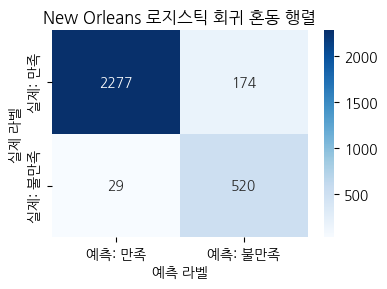


[New Orleans] CatBoost 모델 성능 평가
정확도    : 0.9447
F1 점수   : 0.8551
ROC-AUC  : 0.9835

[정밀도와 재현율]
              precision    recall  f1-score   support

       만족(0)       0.98      0.96      0.97      2451
      불만족(1)       0.82      0.89      0.86       549

    accuracy                           0.94      3000
   macro avg       0.90      0.92      0.91      3000
weighted avg       0.95      0.94      0.95      3000

그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/model_new_orleans_catboost_confusion_matrix.png


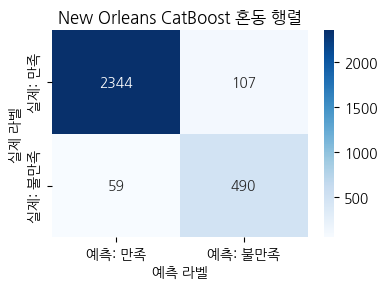


[New Orleans] PyTorch MLP 모델 성능 평가
정확도    : 0.9360
F1 점수   : 0.8452
ROC-AUC  : 0.9859

[정밀도와 재현율]
              precision    recall  f1-score   support

       만족(0)       0.99      0.93      0.96      2451
      불만족(1)       0.76      0.95      0.85       549

    accuracy                           0.94      3000
   macro avg       0.87      0.94      0.90      3000
weighted avg       0.95      0.94      0.94      3000

그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/model_new_orleans_pytorch_mlp_confusion_matrix.png


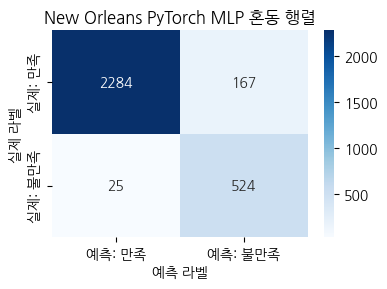

In [29]:
# 앞서 분할한 데이터 중 먼저 뉴올리언스 지역의 데이터를 바탕으로 세 가지 모델의 학습 및 평가를 진행하였습니다.
# 학습이 끝난 후, 각 모델의 예측 확률값과 CatBoost 모델 객체는 최종 비교 시각화 및 SHAP 분석을 위해 딕셔너리에 저장하였습니다.

city = "New Orleans"
X_train, X_test, y_train, y_test = city_datasets[city]

# 로지스틱 회귀
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, lr_preds, lr_proba, "로지스틱 회귀", city)
global_results[city]['lr_proba'] = lr_proba

# CatBoost
count_satisfied = sum(y_train == 0)
count_dissatisfied = sum(y_train == 1)

cb_model = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6,
                              scale_pos_weight=(count_satisfied / count_dissatisfied),
                              eval_metric='AUC', random_seed=42, verbose=0)
cb_model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50)
cb_preds = cb_model.predict(X_test)
cb_proba = cb_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, cb_preds, cb_proba, "CatBoost", city)
global_results[city]['cb_model'] = cb_model
global_results[city]['cb_proba'] = cb_proba

# PyTorch MLP
train_and_evaluate_dl(city, X_train, X_test, y_train, y_test, epochs=30)


[Philly] 로지스틱 회귀 모델 성능 평가
정확도    : 0.9327
F1 점수   : 0.8543
ROC-AUC  : 0.9837

[정밀도와 재현율]
              precision    recall  f1-score   support

       만족(0)       0.99      0.93      0.96      2376
      불만족(1)       0.78      0.95      0.85       624

    accuracy                           0.93      3000
   macro avg       0.88      0.94      0.91      3000
weighted avg       0.94      0.93      0.94      3000

그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/model_philly_로지스틱_회귀_confusion_matrix.png


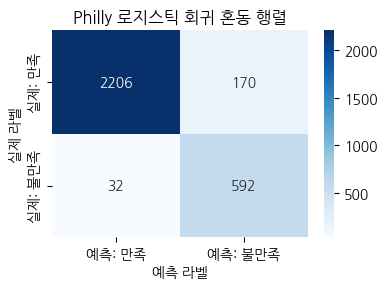


[Philly] CatBoost 모델 성능 평가
정확도    : 0.9367
F1 점수   : 0.8580
ROC-AUC  : 0.9830

[정밀도와 재현율]
              precision    recall  f1-score   support

       만족(0)       0.98      0.94      0.96      2376
      불만족(1)       0.80      0.92      0.86       624

    accuracy                           0.94      3000
   macro avg       0.89      0.93      0.91      3000
weighted avg       0.94      0.94      0.94      3000

그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/model_philly_catboost_confusion_matrix.png


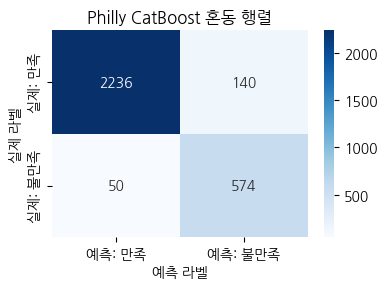


[Philly] PyTorch MLP 모델 성능 평가
정확도    : 0.9307
F1 점수   : 0.8512
ROC-AUC  : 0.9848

[정밀도와 재현율]
              precision    recall  f1-score   support

       만족(0)       0.99      0.92      0.95      2376
      불만족(1)       0.77      0.95      0.85       624

    accuracy                           0.93      3000
   macro avg       0.88      0.94      0.90      3000
weighted avg       0.94      0.93      0.93      3000

그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/model_philly_pytorch_mlp_confusion_matrix.png


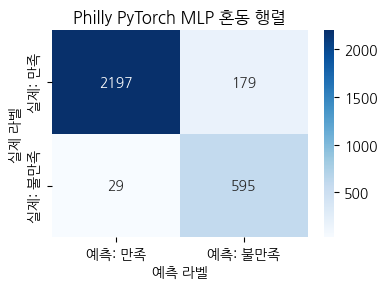

In [30]:
# 필라델피아 지역

city = "Philly"
X_train, X_test, y_train, y_test = city_datasets[city]

# 로지스틱 회귀
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, lr_preds, lr_proba, "로지스틱 회귀", city)
global_results[city]['lr_proba'] = lr_proba

# CatBoost
count_satisfied = sum(y_train == 0)
count_dissatisfied = sum(y_train == 1)

cb_model = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6,
                              scale_pos_weight=(count_satisfied / count_dissatisfied),
                              eval_metric='AUC', random_seed=42, verbose=0)
cb_model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50)
cb_preds = cb_model.predict(X_test)
cb_proba = cb_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, cb_preds, cb_proba, "CatBoost", city)
global_results[city]['cb_model'] = cb_model
global_results[city]['cb_proba'] = cb_proba

# PyTorch MLP
train_and_evaluate_dl(city, X_train, X_test, y_train, y_test, epochs=30)


[Tucson] 로지스틱 회귀 모델 성능 평가
정확도    : 0.9433
F1 점수   : 0.8952
ROC-AUC  : 0.9876

[정밀도와 재현율]
              precision    recall  f1-score   support

       만족(0)       0.98      0.94      0.96      2234
      불만족(1)       0.85      0.95      0.90       766

    accuracy                           0.94      3000
   macro avg       0.91      0.94      0.93      3000
weighted avg       0.95      0.94      0.94      3000

그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/model_tucson_로지스틱_회귀_confusion_matrix.png


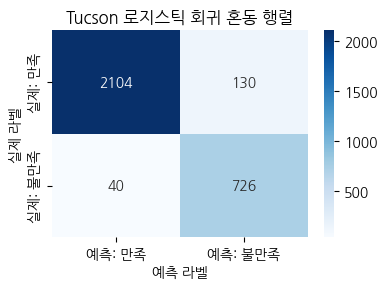


[Tucson] CatBoost 모델 성능 평가
정확도    : 0.9447
F1 점수   : 0.8957
ROC-AUC  : 0.9864

[정밀도와 재현율]
              precision    recall  f1-score   support

       만족(0)       0.98      0.95      0.96      2234
      불만족(1)       0.86      0.93      0.90       766

    accuracy                           0.94      3000
   macro avg       0.92      0.94      0.93      3000
weighted avg       0.95      0.94      0.95      3000

그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/model_tucson_catboost_confusion_matrix.png


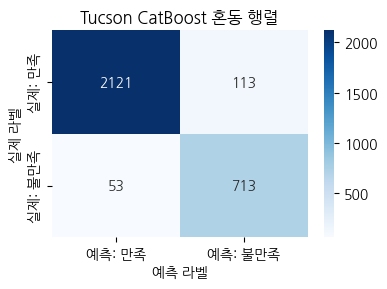


[Tucson] PyTorch MLP 모델 성능 평가
정확도    : 0.9370
F1 점수   : 0.8857
ROC-AUC  : 0.9876

[정밀도와 재현율]
              precision    recall  f1-score   support

       만족(0)       0.98      0.93      0.96      2234
      불만족(1)       0.83      0.96      0.89       766

    accuracy                           0.94      3000
   macro avg       0.90      0.94      0.92      3000
weighted avg       0.94      0.94      0.94      3000

그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/model_tucson_pytorch_mlp_confusion_matrix.png


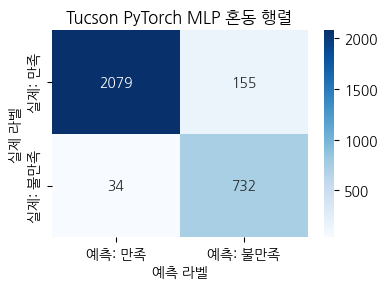

In [31]:
# 투손 지역

city = "Tucson"
X_train, X_test, y_train, y_test = city_datasets[city]

# 로지스틱 회귀
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, lr_preds, lr_proba, "로지스틱 회귀", city)
global_results[city]['lr_proba'] = lr_proba

# CatBoost
count_satisfied = sum(y_train == 0)
count_dissatisfied = sum(y_train == 1)

cb_model = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6,
                              scale_pos_weight=(count_satisfied / count_dissatisfied),
                              eval_metric='AUC', random_seed=42, verbose=0)
cb_model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50)
cb_preds = cb_model.predict(X_test)
cb_proba = cb_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, cb_preds, cb_proba, "CatBoost", city)
global_results[city]['cb_model'] = cb_model
global_results[city]['cb_proba'] = cb_proba

# PyTorch MLP
train_and_evaluate_dl(city, X_train, X_test, y_train, y_test, epochs=30)

## 5. 결과 시각화 및 해석

도시별 ROC 곡선, SHAP Summary/의존성 그래프, 종합 성능표, 오류 분석 결과를 생성하고 `output/`에 저장합니다.


그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/new_orleans_roc_curve.png


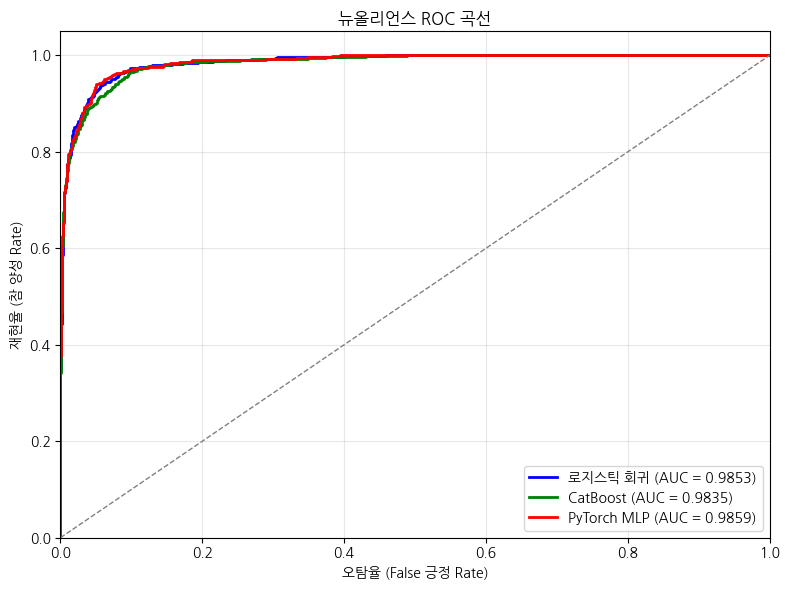

그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/new_orleans_shap_summary.png


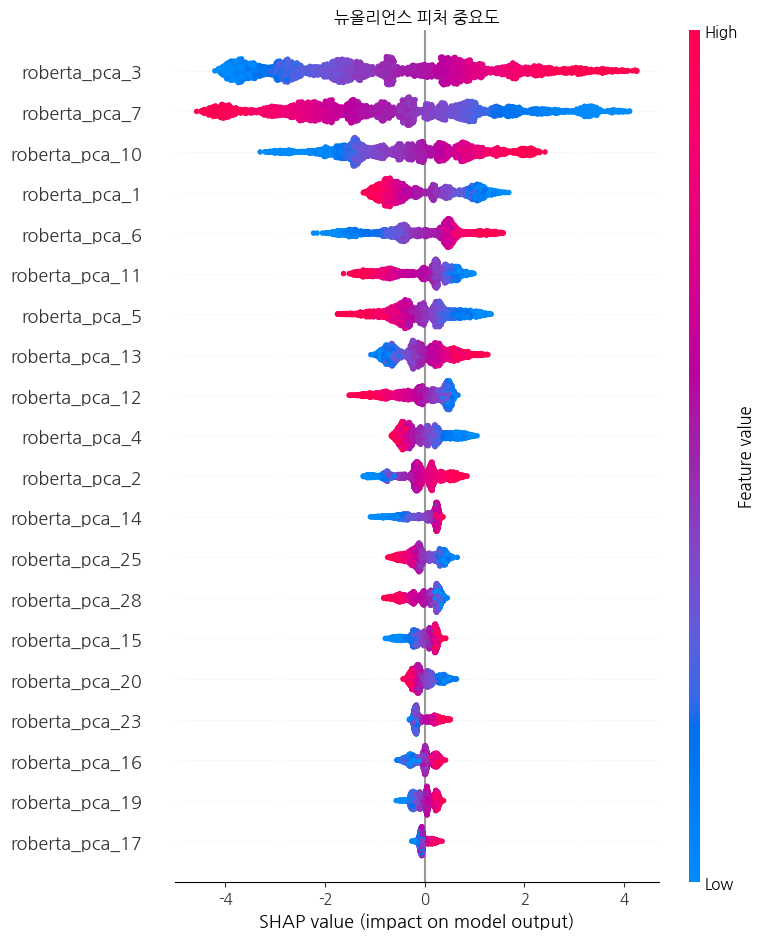

그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/new_orleans_shap_dependence.png


<Figure size 800x500 with 0 Axes>

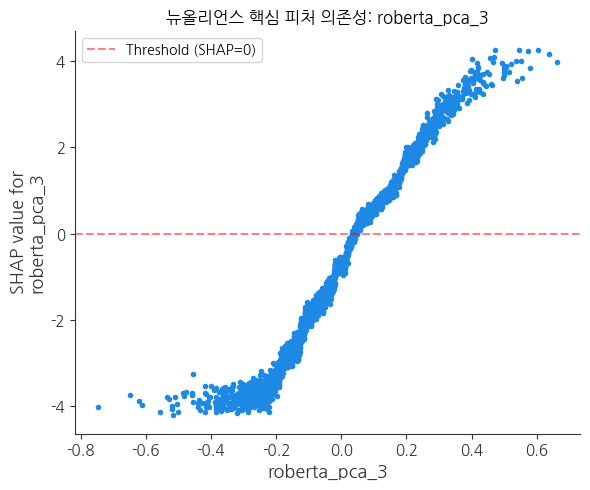

In [32]:
# 앞서 저장해둔 예측 결과와 모델 객체를 바탕으로 뉴올리언스 지역의 시각화 리포트를 생성하였습니다.
# 세 모델의 성능을 비교하는 ROC 곡선, 핵심 요인을 분석하는 SHAP 요약 그래프 및 의존성 그래프을 시각화하였습니다.
# 마지막으로 전체 데이터의 SHAP 값을 군집화(Clustering)하는 Heatmap Plot을 추가하여, 개별 리뷰가 아닌 '전체 고객의 불만 유형(거시 패턴)'이 어떻게 세분화되는지 거시적인 마케팅 인사이트를 도출하였습니다.

city = "New Orleans"
X_train, X_test, y_train, y_test = city_datasets[city]
lr_probs = global_results[city]['lr_proba']
cb_probs = global_results[city]['cb_proba']
dl_probs = global_results[city]['dl_proba']
cb_model = global_results[city]['cb_model']

# 다중 모델 ROC 곡선
plt.figure(figsize=(8, 6))
for name, probs, color in [("로지스틱 회귀", lr_probs, 'blue'),
                           ("CatBoost", cb_probs, 'green'),
                           ("PyTorch MLP", dl_probs, 'red')]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc(fpr, tpr):.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('오탐율 (False 긍정 Rate)')
plt.ylabel('재현율 (참 양성 Rate)')
plt.title('뉴올리언스 ROC 곡선')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
save_current_figure('new_orleans_roc_curve.png')
plt.show()

explainer = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_test)

# SHAP 요약 그래프
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("뉴올리언스 피처 중요도")
plt.tight_layout()
save_current_figure('new_orleans_shap_summary.png')
plt.show()

# SHAP 의존성 그래프
top_feature_idx = np.argmax(np.abs(shap_values).mean(axis=0))
top_feature_name = X_test.columns[top_feature_idx]

plt.figure(figsize=(8, 5))
shap.dependence_plot(top_feature_idx, shap_values, X_test, interaction_index=None, show=False)
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Threshold (SHAP=0)')
plt.title(f"뉴올리언스 핵심 피처 의존성: {top_feature_name}")
plt.legend()
plt.tight_layout()
save_current_figure('new_orleans_shap_dependence.png')
plt.show()

그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/philly_roc_curve.png


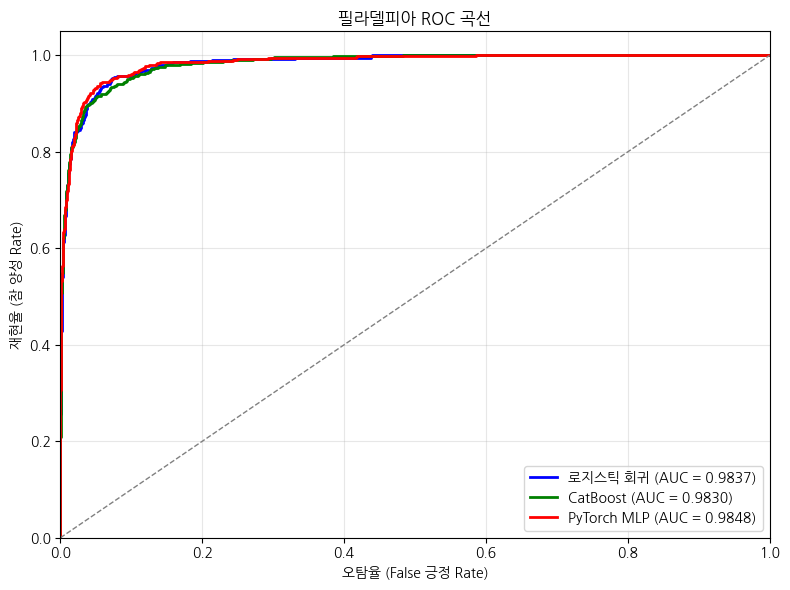

그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/philly_shap_summary.png


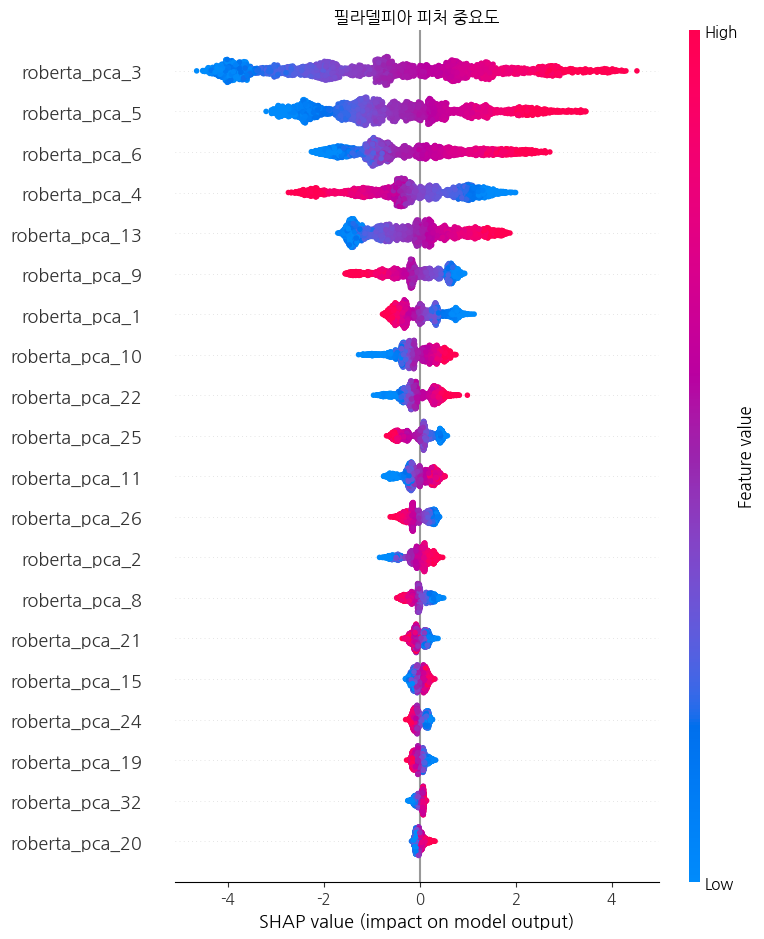

그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/philly_shap_dependence.png


<Figure size 800x500 with 0 Axes>

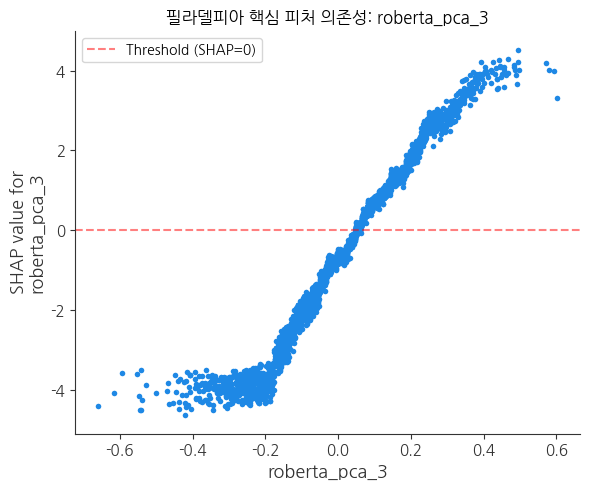

In [33]:
# 필라델피아입니다.

city = "Philly"
X_train, X_test, y_train, y_test = city_datasets[city]
lr_probs = global_results[city]['lr_proba']
cb_probs = global_results[city]['cb_proba']
dl_probs = global_results[city]['dl_proba']
cb_model = global_results[city]['cb_model']

# 다중 모델 ROC 곡선
plt.figure(figsize=(8, 6))
for name, probs, color in [("로지스틱 회귀", lr_probs, 'blue'),
                           ("CatBoost", cb_probs, 'green'),
                           ("PyTorch MLP", dl_probs, 'red')]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc(fpr, tpr):.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('오탐율 (False 긍정 Rate)')
plt.ylabel('재현율 (참 양성 Rate)')
plt.title('필라델피아 ROC 곡선')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
save_current_figure('philly_roc_curve.png')
plt.show()

explainer = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_test)

# SHAP 요약 그래프
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("필라델피아 피처 중요도")
plt.tight_layout()
save_current_figure('philly_shap_summary.png')
plt.show()

# SHAP 의존성 그래프
top_feature_idx = np.argmax(np.abs(shap_values).mean(axis=0))
top_feature_name = X_test.columns[top_feature_idx]

plt.figure(figsize=(8, 5))
shap.dependence_plot(top_feature_idx, shap_values, X_test, interaction_index=None, show=False)
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Threshold (SHAP=0)')
plt.title(f"필라델피아 핵심 피처 의존성: {top_feature_name}")
plt.legend()
plt.tight_layout()
save_current_figure('philly_shap_dependence.png')
plt.show()


그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/tucson_roc_curve.png


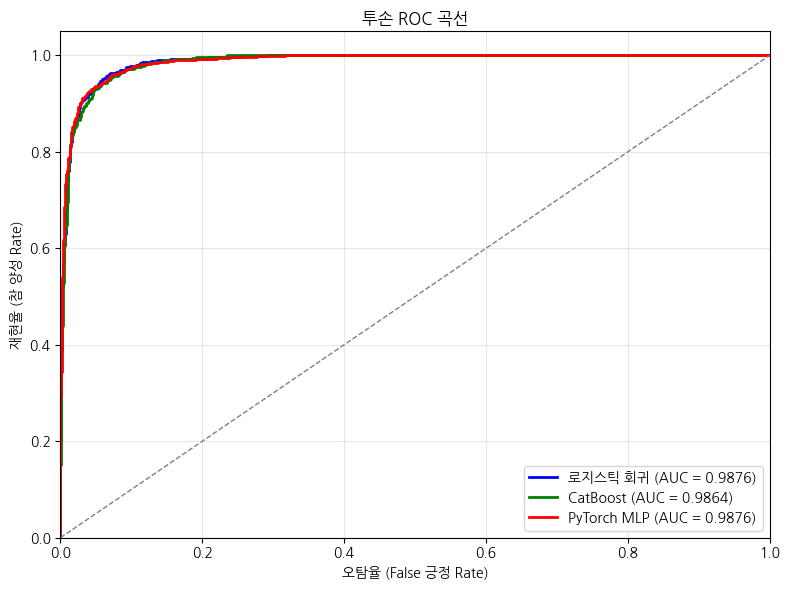

그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/tucson_shap_summary.png


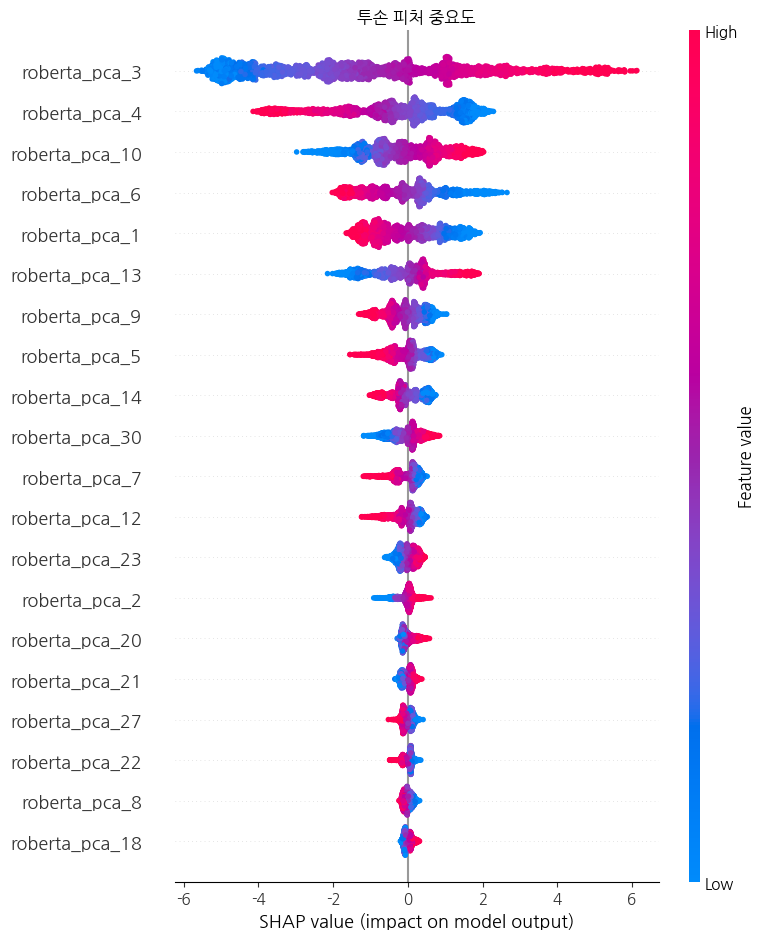

그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/tucson_shap_dependence.png


<Figure size 800x500 with 0 Axes>

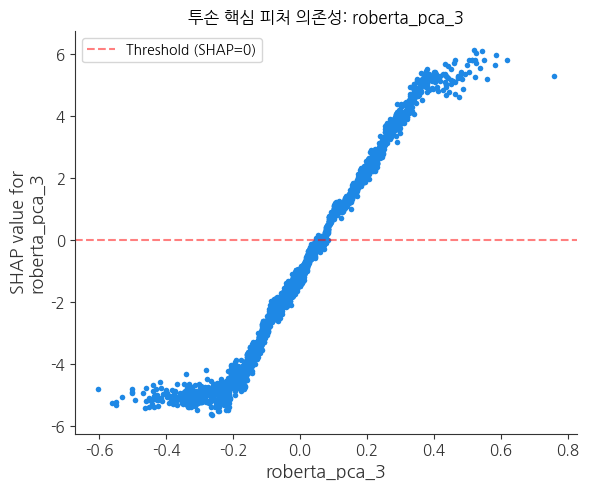

In [34]:
# 투손입니다.

city = "Tucson"
X_train, X_test, y_train, y_test = city_datasets[city]
lr_probs = global_results[city]['lr_proba']
cb_probs = global_results[city]['cb_proba']
dl_probs = global_results[city]['dl_proba']
cb_model = global_results[city]['cb_model']

# 다중 모델 ROC 곡선
plt.figure(figsize=(8, 6))
for name, probs, color in [("로지스틱 회귀", lr_probs, 'blue'),
                           ("CatBoost", cb_probs, 'green'),
                           ("PyTorch MLP", dl_probs, 'red')]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc(fpr, tpr):.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('오탐율 (False 긍정 Rate)')
plt.ylabel('재현율 (참 양성 Rate)')
plt.title('투손 ROC 곡선')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
save_current_figure('tucson_roc_curve.png')
plt.show()

explainer = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_test)

# SHAP 요약 그래프
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("투손 피처 중요도")
plt.tight_layout()
save_current_figure('tucson_shap_summary.png')
plt.show()

# SHAP 의존성 그래프
top_feature_idx = np.argmax(np.abs(shap_values).mean(axis=0))
top_feature_name = X_test.columns[top_feature_idx]

plt.figure(figsize=(8, 5))
shap.dependence_plot(top_feature_idx, shap_values, X_test, interaction_index=None, show=False)
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Threshold (SHAP=0)')
plt.title(f"투손 핵심 피처 의존성: {top_feature_name}")
plt.legend()
plt.tight_layout()
save_current_figure('tucson_shap_dependence.png')
plt.show()

성능 요약표 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/tables/model_metrics_summary.csv
그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/model_metrics_comparison.png


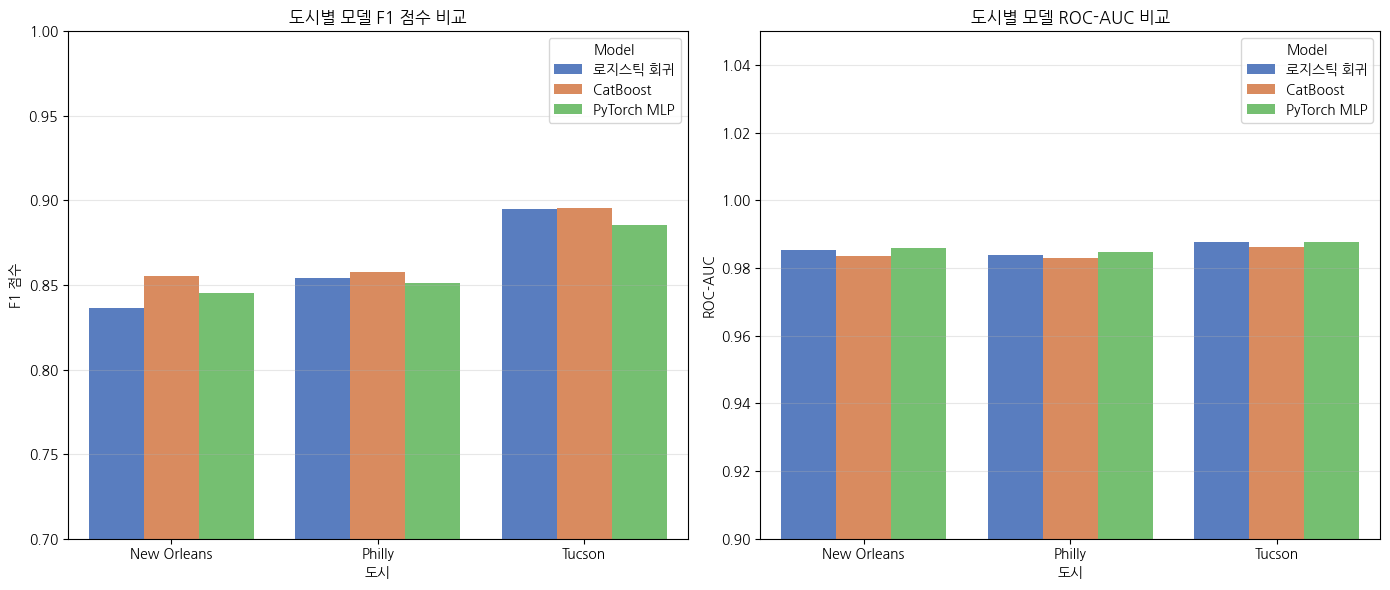

In [35]:
# 3개 도시와 3가지 모델의 성능 지표(F1 점수, ROC-AUC)를 하나의 그래프로 통합하여 비교 분석하였습니다.
# 전역 딕셔너리에 저장된 예측 확률값을 활용하여 각 환경별 지표를 재산출하고, 이를 바 차트로 시각화하였습니다.

data_rows = []

for city in city_datasets.keys():
    _, _, _, y_test = city_datasets[city]

    lr_proba = global_results[city]['lr_proba']
    cb_proba = global_results[city]['cb_proba']
    dl_probs = global_results[city]['dl_proba']

    lr_pred = (lr_proba >= 0.5).astype(int)
    cb_pred = (cb_proba >= 0.5).astype(int)
    dl_pred = (dl_probs >= 0.5).astype(int)

    for model_name, preds, probas in [("로지스틱 회귀", lr_pred, lr_proba),
                                      ("CatBoost", cb_pred, cb_proba),
                                      ("PyTorch MLP", dl_pred, dl_probs)]:
        f1 = f1_score(y_test, preds)
        auc_val = roc_auc_score(y_test, probas)
        data_rows.append({"City": city, "Model": model_name, "F1 점수": f1, "ROC-AUC": auc_val})

df_metrics = pd.DataFrame(data_rows)
metrics_path = TABLE_DIR / 'model_metrics_summary.csv'
df_metrics.to_csv(metrics_path, index=False)
print(f'성능 요약표 저장 완료: {metrics_path}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x="City", y="F1 점수", hue="Model", data=df_metrics, ax=axes[0], palette="muted")
axes[0].set_title("도시별 모델 F1 점수 비교")
axes[0].set_ylim(0.7, 1.0)
axes[0].set_xlabel("도시")
axes[0].grid(axis='y', alpha=0.3)

sns.barplot(x="City", y="ROC-AUC", hue="Model", data=df_metrics, ax=axes[1], palette="muted")
axes[1].set_title("도시별 모델 ROC-AUC 비교")
axes[1].set_ylim(0.9, 1.05)
axes[1].set_xlabel("도시")
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
save_current_figure('model_metrics_comparison.png')
plt.show()

오류 분석표 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/tables/error_analysis_new_orleans.csv
그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/error_analysis_new_orleans.png


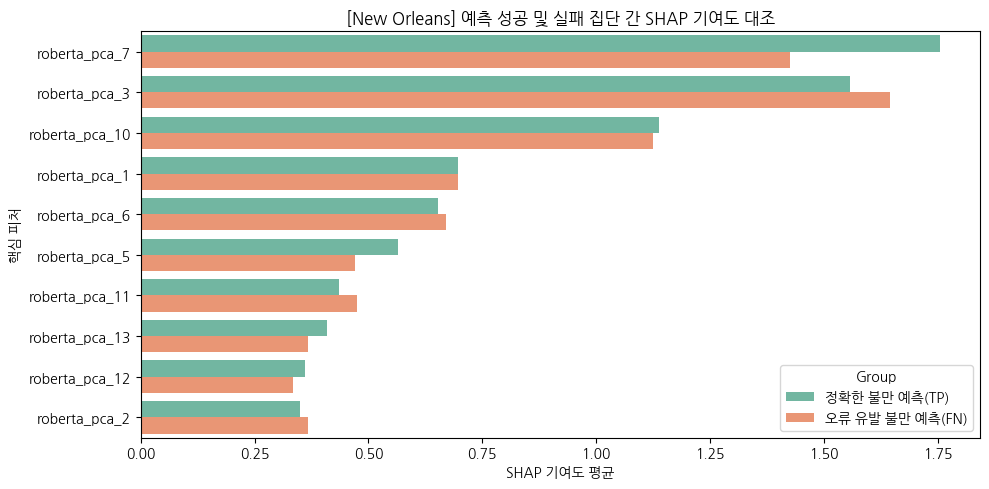

오류 분석표 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/tables/error_analysis_philly.csv
그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/error_analysis_philly.png


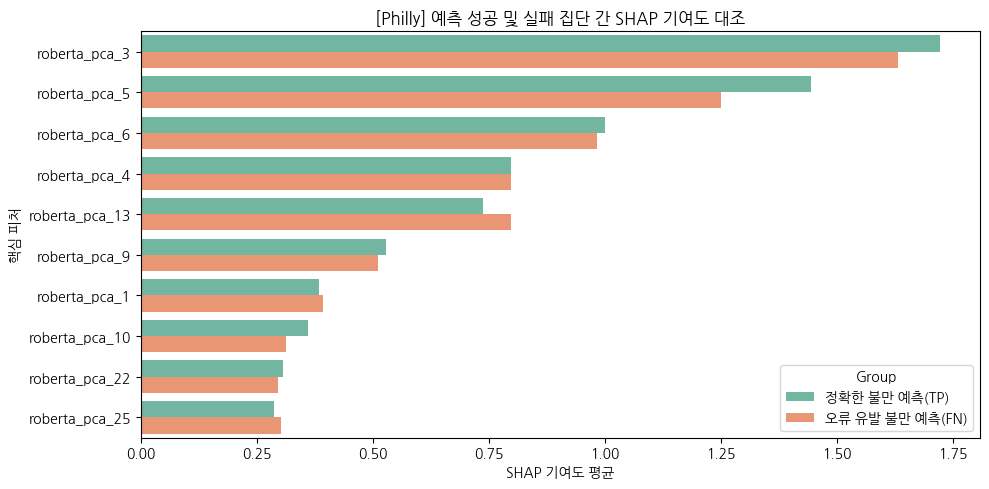

오류 분석표 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/tables/error_analysis_tucson.csv
그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/error_analysis_tucson.png


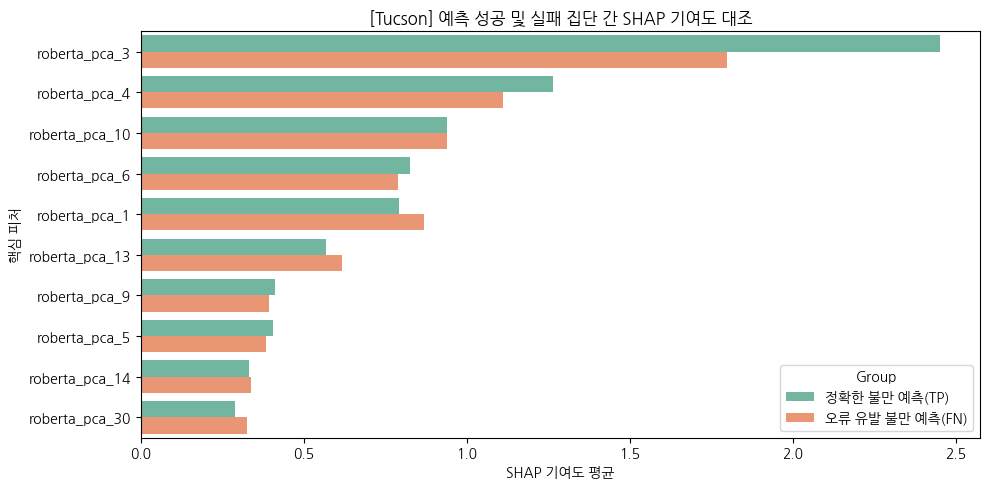

In [36]:
# 모델이 예측에 실패한 원인을 규명하기 위해 도시별 오류 분석(오류 분석)을 수행하였습니다.
# 정답을 맞춘 불만족 리뷰(참 양성)와 만족 리뷰로 오해한 불만족 리뷰(거짓 음성)의 SHAP 값을 대조하여 모델이 분류에 혼선을 겪은 요인을 추적하였습니다.

for city in city_datasets.keys():
    X_train, X_test, y_train, y_test = city_datasets[city]
    cb_model = global_results[city]['cb_model']
    cb_preds = cb_model.predict(X_test)

    explainer = shap.TreeExplainer(cb_model)
    shap_values = explainer.shap_values(X_test)

    tp_idx = np.where((y_test == 1) & (cb_preds == 1))[0]
    fn_idx = np.where((y_test == 1) & (cb_preds == 0))[0]

    if len(fn_idx) > 0:
        tp_shap_mean = np.abs(shap_values[tp_idx]).mean(axis=0)
        fn_shap_mean = np.abs(shap_values[fn_idx]).mean(axis=0)

        df_error = pd.DataFrame({
            'Feature': X_test.columns,
            '정확한 불만 예측(TP)': tp_shap_mean,
            '오류 유발 불만 예측(FN)': fn_shap_mean
        }).sort_values(by='정확한 불만 예측(TP)', ascending=False).head(10)

        error_path = TABLE_DIR / f"error_analysis_{slugify(city)}.csv"
        df_error.to_csv(error_path, index=False)
        print(f'오류 분석표 저장 완료: {error_path}')

        df_error_melt = df_error.melt(id_vars='Feature', var_name='Group', value_name='Mean SHAP')

        plt.figure(figsize=(10, 5))
        sns.barplot(x='Mean SHAP', y='Feature', hue='Group', data=df_error_melt, palette='Set2')
        plt.title(f"[{city}] 예측 성공 및 실패 집단 간 SHAP 기여도 대조")
        plt.xlabel("SHAP 기여도 평균")
        plt.ylabel("핵심 피처")
        plt.tight_layout()
        save_current_figure(f"error_analysis_{slugify(city)}.png")
        plt.show()

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

# 특정 PCA Component의 고정값(높은 값/낮은 값)에 매핑되는 원본 텍스트를 추출하여 해당 차원의 언어학적/문맥적 의미를 해석하기 위한 역추적 분석 함수입니다.

def analyze_pca_meaning(city_name, pca_feature_name, top_n=5):
    urls = data_sources[city_name]
    df_raw = read_csv_with_fallback(urls["raw_path"], urls["raw_url"])
    df_pca = read_csv_with_fallback(urls["pca_path"], urls["pca_url"])

    text_col = 'text' if 'text' in df_raw.columns else df_raw.select_dtypes(include=[object]).columns[0]

    df_analysis = pd.DataFrame({
        'text': df_raw[text_col],
        'pca_value': df_pca[pca_feature_name]
    })

    top_reviews = df_analysis.sort_values(by='pca_value', ascending=False).head(top_n)
    bottom_reviews = df_analysis.sort_values(by='pca_value', ascending=True).head(top_n)

    print(f"[{city_name}] {pca_feature_name} 차원 해석")

    print(f"\n  [높은 값]")
    for row in top_reviews.itertuples():
        print(f"  ({row.pca_value:.4f}) {row.text[:120]}...")

    print(f"\n  [낮은 값]")
    for row in bottom_reviews.itertuples():
        print(f"  ({row.pca_value:.4f}) {row.text[:120]}...")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    vectorizer = CountVectorizer(stop_words='english', max_features=10)

    try:
        X_top = vectorizer.fit_transform(top_reviews['text'])
        top_words = pd.DataFrame(X_top.toarray(), columns=vectorizer.get_feature_names_out()).sum().sort_values(ascending=False)
        sns.barplot(x=top_words.values, y=top_words.index, ax=axes[0], palette='bone')
        axes[0].set_title(f"{pca_feature_name} (High)")
        axes[0].set_xlabel("빈도")
    except Exception:
        axes[0].text(0.5, 0.5, '데이터 부족', ha='center')

    try:
        X_bottom = vectorizer.fit_transform(bottom_reviews['text'])
        bottom_words = pd.DataFrame(X_bottom.toarray(), columns=vectorizer.get_feature_names_out()).sum().sort_values(ascending=False)
        sns.barplot(x=bottom_words.values, y=bottom_words.index, ax=axes[1], palette='bone')
        axes[1].set_title(f"{pca_feature_name} (Low)")
        axes[1].set_xlabel("빈도")
    except Exception:
        axes[1].text(0.5, 0.5, '데이터 부족', ha='center')

    plt.tight_layout()
    save_current_figure(f"pca_meaning_{slugify(city_name)}_{pca_feature_name}.png")
    plt.show()

로컬 CSV 불러오기: /content/drive/MyDrive/ml_project/Team-6/data/processed/yelp_subset_new_orleans_15k_features.csv
로컬 CSV 불러오기: /content/drive/MyDrive/ml_project/Team-6/data/embeddings/new_orleans_pca_32.csv
[New Orleans] roberta_pca_3 차원 해석

  [높은 값]
  (0.6626) 0 if I could 
Couldn't order my meal before arriving cause they wouldn't answer. Came to store to order & wouldn't open ...
  (0.6513) Really awful.  Just waited here for more than 20 min and the place is not even full.  The service was non existent.  Jus...
  (0.6384) Omg...homeless dudes passed.out or maybe dead in the first booth.  I just wanted a large iced coffee.  The girl behind t...

  [낮은 값]
  (-0.7473) I have been wanting Shrimp and Grits from this restaurant ever since I saw a picture floating on Instagram! This place d...
  (-0.6480) I absolutely LOVE Max Well!!! Mardi Gras food got me all heavy feeling, so naturally, I was craving a big salad Max Well...
  (-0.6382) My husband and I truly enjoyed this delicious meal las

/tmp/ipykernel_4512/3754386887.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_words.values, y=top_words.index, ax=axes[0], palette='bone')
/tmp/ipykernel_4512/3754386887.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_words.values, y=bottom_words.index, ax=axes[1], palette='bone')


그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/pca_meaning_new_orleans_roberta_pca_3.png


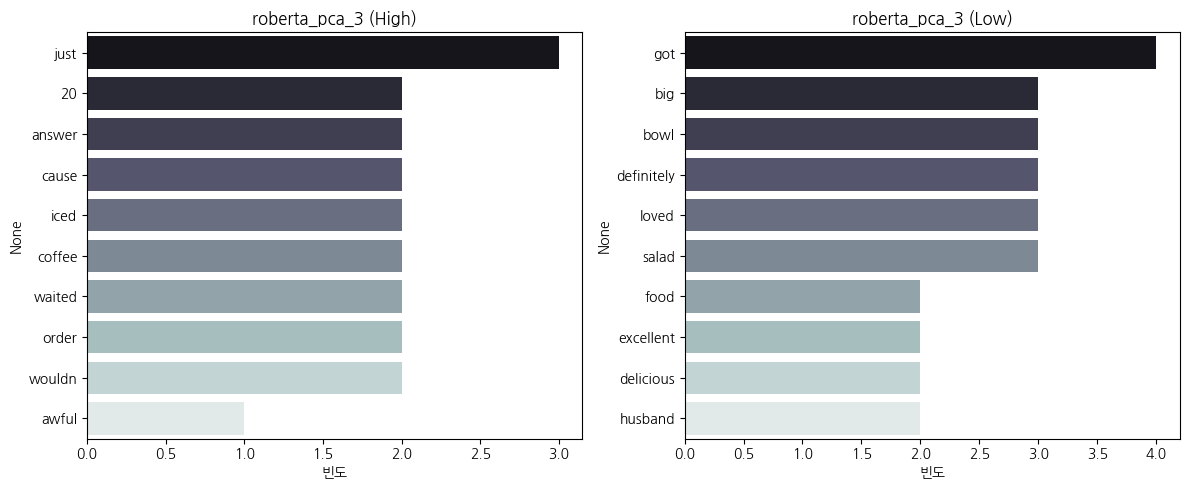

In [38]:
analyze_pca_meaning(city_name="New Orleans", pca_feature_name="roberta_pca_3", top_n=3)

로컬 CSV 불러오기: /content/drive/MyDrive/ml_project/Team-6/data/processed/yelp_subset_philly_15k_features.csv
로컬 CSV 불러오기: /content/drive/MyDrive/ml_project/Team-6/data/embeddings/philly_pca_32.csv
[Philly] roberta_pca_3 차원 해석

  [높은 값]
  (0.7041) they need to train their employees the correct way ...worst service ever ....they are dispicable !! if the phone number ...
  (0.6804) About a week ago , I went there to pick up an order . It was around 9:30 pm . The bouncer asked me if I was there to pic...
  (0.6706) I have had 2 racist encounters within a 3 month span .i am a you g African American woman . This is the closet market.  ...

  [낮은 값]
  (-0.6783) Restaurant is clean, staff are pleasant and food is excellent! I came alone the first time and had a wrap with authentic...
  (-0.6605) My wife and I tried this place out for the first time and we really enjoyed it! The environment inside is cozy and comfo...
  (-0.6322) The decor looks great! And even though I'm vegan, I've eaten here a n

/tmp/ipykernel_4512/3754386887.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_words.values, y=top_words.index, ax=axes[0], palette='bone')
/tmp/ipykernel_4512/3754386887.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_words.values, y=bottom_words.index, ax=axes[1], palette='bone')


그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/pca_meaning_philly_roberta_pca_3.png


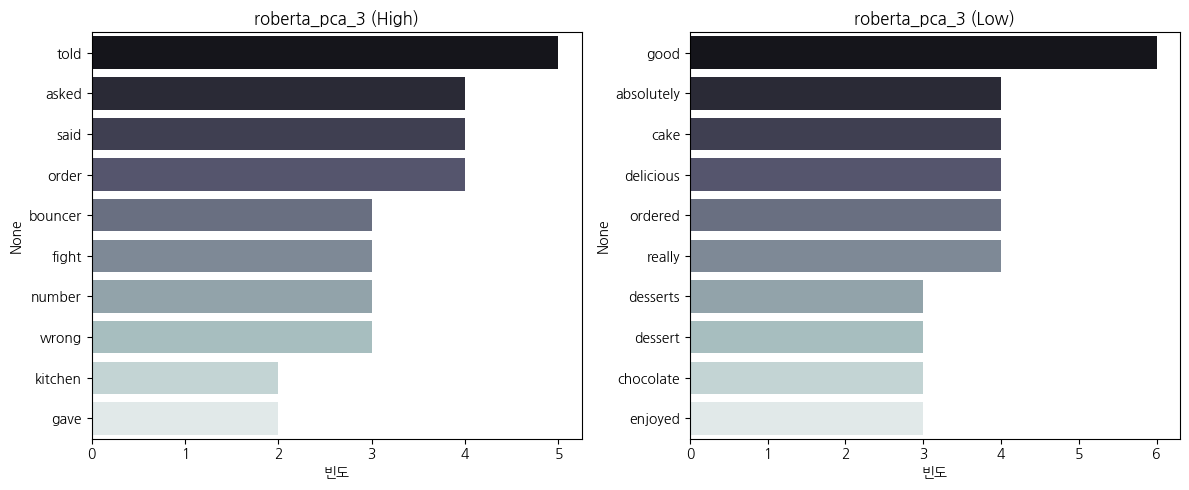

In [39]:
analyze_pca_meaning(city_name="Philly", pca_feature_name="roberta_pca_3", top_n=3)

로컬 CSV 불러오기: /content/drive/MyDrive/ml_project/Team-6/data/processed/yelp_subset_tucson_15k_features.csv
로컬 CSV 불러오기: /content/drive/MyDrive/ml_project/Team-6/data/embeddings/tucson_pca_32.csv
[Tucson] roberta_pca_3 차원 해석

  [높은 값]
  (0.7595) I recently  visited the Denny's  on 22nd & Alvernon for lunch l Will not go back to this location
Service was poor . Aft...
  (0.7514) after i went into the place they had the new computer up and running i like it nice but only wanted a cup of coffee i de...
  (0.6876) Rude manager Andrew , bad customer service , this place was never really clean now that I'm  speaking of the negatives, ...

  [낮은 값]
  (-0.7341) Tried this truck today at my place of employment! I had the 3 tacos special, 1 chicken, 1 carne Asada, and 1 carnitas!
A...
  (-0.6150) This is my first time going to this restaurant, and let me tell you that it was excellent! Service is superb! The food i...
  (-0.6104) This is now our favorite new restaurant! Loved everything we ordered!

/tmp/ipykernel_4512/3754386887.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_words.values, y=top_words.index, ax=axes[0], palette='bone')
/tmp/ipykernel_4512/3754386887.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_words.values, y=bottom_words.index, ax=axes[1], palette='bone')


그래프 저장 완료: /content/drive/MyDrive/ml_project/Team-6/output/figures/pca_meaning_tucson_roberta_pca_3.png


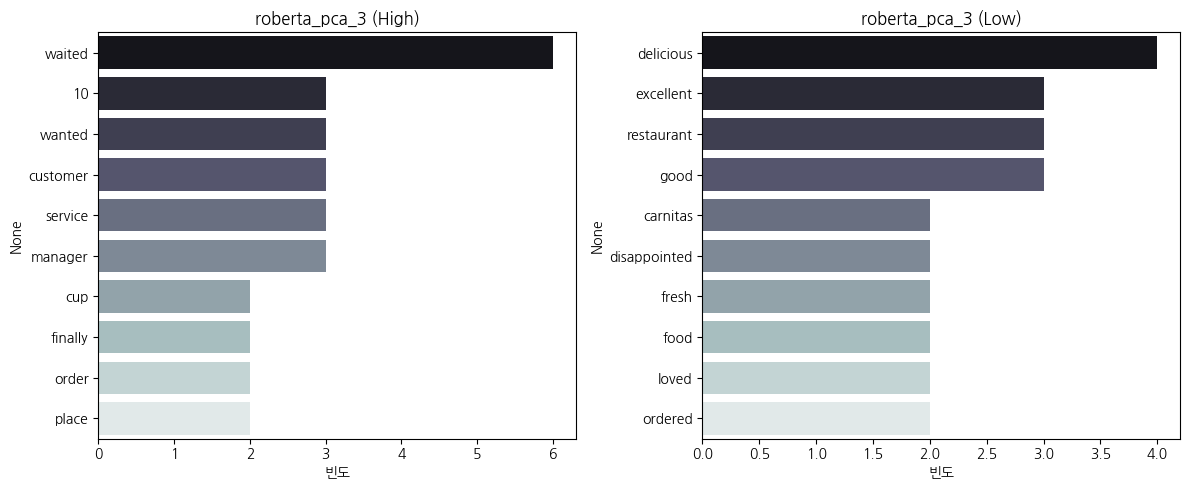

In [40]:
analyze_pca_meaning(city_name="Tucson", pca_feature_name="roberta_pca_3", top_n=3)